01_Banking_Data_Analytics.ipynb

1. Project Introduction
2. Business Problem
3. Project Objectives
4. Import Libraries
5. Load Banking Datasets
6. Dataset Overview
7. Data Dictionary
8. Data Quality Assessment
9. Exploratory Data Analysis (EDA)
10. Business Insights
11. Conclusion

# AI Banking & Financial Intelligence Platform

## Module 01 : Banking Data Analytics

### Project Description

This project aims to develop an AI-powered Banking and Financial Intelligence Platform using Machine Learning techniques. The first module focuses on understanding and analyzing banking data before building predictive machine learning models.

The datasets include customer information, accounts, loans, transactions, branches, addresses, account types, account statuses, customer types, transaction types, and loan statuses.

This module performs data loading, exploration, profiling, visualization, and preprocessing to prepare the data for future machine learning tasks.

# Business Problem

Banks generate large volumes of customer, transaction, and loan data every day. Before building AI models for fraud detection, loan approval prediction, customer segmentation, and financial analytics, it is essential to understand the data.

Poor data quality can lead to inaccurate machine learning predictions. Therefore, this module focuses on analyzing the data, identifying inconsistencies, handling missing values, and preparing high-quality datasets.

# Objectives

• Load all banking datasets

• Understand the structure of each dataset

• Perform data profiling

• Detect missing values

• Detect duplicate records

• Analyze numerical and categorical features

• Visualize important business information

• Prepare the data for Machine Learning

In [1]:
# ==========================================================
# MODULE 01 : IMPORT LIBRARIES
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("="*60)
print("All Libraries Imported Successfully")
print("="*60)

All Libraries Imported Successfully


# Load Banking Datasets

modules/
    Module_01_Data_Analytics/
        notebook/

datasets/raw/

        

In [2]:
from pathlib import Path

# Project root (three levels up from notebook/)
project_root = Path.cwd().parents[2]

data_path = project_root/"AI_Banking_Financial_Intelligence"/ "datasets" / "raw"

print(data_path)

/mnt/Project/mlm/AI_Banking_Financial_Intelligence/datasets/raw


In [3]:
accounts = pd.read_csv(data_path / "accounts.csv")
customers = pd.read_csv(data_path / "customers.csv")
transactions = pd.read_csv(data_path / "transactions.csv")
loans = pd.read_csv(data_path / "loans.csv")
branches = pd.read_csv(data_path / "branches.csv")
addresses = pd.read_csv(data_path / "addresses.csv")

account_types = pd.read_csv(data_path / "account_types.csv")
account_statuses = pd.read_csv(data_path / "account_statuses.csv")
customer_types = pd.read_csv(data_path / "customer_types.csv")
loan_statuses = pd.read_csv(data_path / "loan_statuses.csv")
transaction_types = pd.read_csv(data_path / "transaction_types.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [4]:
datasets = {
    "Customers": customers,
    "Accounts": accounts,
    "Transactions": transactions,
    "Loans": loans,
    "Branches": branches,
    "Addresses": addresses,
    "Account Types": account_types,
    "Account Status": account_statuses,
    "Customer Types": customer_types,
    "Loan Status": loan_statuses,
    "Transaction Types": transaction_types
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Customers,1111,6
1,Accounts,1667,6
2,Transactions,50000,8
3,Loans,333,7
4,Branches,50,3
5,Addresses,1222,4
6,Account Types,5,2
7,Account Status,3,2
8,Customer Types,3,2
9,Loan Status,3,2


# Dataset Profiling

The objective of this section is to understand the structure and quality of each banking dataset before performing exploratory data analysis and machine learning.


In [5]:
def profile_dataset(df, name):
    print("=" * 80)
    print(f"DATASET : {name}")
    print("=" * 80)

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nMemory Usage")
    print(df.memory_usage(deep=True))

    print("\nFirst Five Rows")
    display(df.head())

    print("\nLast Five Rows")
    display(df.tail())

In [6]:
for name, df in datasets.items():
    profile_dataset(df, name)

DATASET : Customers

Shape
(1111, 6)

Columns
['CustomerID', 'FirstName', 'LastName', 'DateOfBirth', 'AddressID', 'CustomerTypeID']

Data Types
CustomerID        int64
FirstName           str
LastName            str
DateOfBirth         str
AddressID         int64
CustomerTypeID    int64
dtype: object

Missing Values
CustomerID         0
FirstName         22
LastName          23
DateOfBirth        0
AddressID          0
CustomerTypeID     0
dtype: int64

Duplicate Rows
11

Memory Usage
Index               132
CustomerID         8888
FirstName         69264
LastName          69435
DateOfBirth       91556
AddressID          8888
CustomerTypeID     8888
dtype: int64

First Five Rows


,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID
0,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1
1,10983,NaN,Battle,1963-02-01 00:00:00.000000,958,2
2,10837,Angelena,Harrington,1964-03-25 00:00:00.000000,86,3
3,10107,Remona,Glass,1965-09-16 00:00:00.000000,595,1
4,10553,King,Becker,1966-02-20 00:00:00.000000,969,3



Last Five Rows


,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID
1106,10360,Sheldon,Vang,1976-09-09 00:00:00.000000,235,3
1107,11071,Adam,NaN,1980-12-19 00:00:00.000000,391,3
1108,10605,Eugene,Navarro,1997-12-02 00:00:00.000000,401,3
1109,10257,Lad,Castro,1979-10-31 00:00:00.000000,1180,3
1110,10116,Rebecka,Petty,1973-07-11 00:00:00.000000,234,2


DATASET : Accounts

Shape
(1667, 6)

Columns
['AccountID', 'CustomerID', 'AccountTypeID', 'AccountStatusID', 'Balance', 'OpeningDate']

Data Types
AccountID            int64
CustomerID           int64
AccountTypeID        int64
AccountStatusID      int64
Balance            float64
OpeningDate            str
dtype: object

Missing Values
AccountID           0
CustomerID          0
AccountTypeID       0
AccountStatusID     0
Balance             0
OpeningDate        33
dtype: int64

Duplicate Rows
16

Memory Usage
Index                 132
AccountID           13336
CustomerID          13336
AccountTypeID       13336
AccountStatusID     13336
Balance             13336
OpeningDate        136678
dtype: int64

First Five Rows


...

,LoanStatusID,StatusName
0,1,Active
1,2,Paid Off
2,3,Overdue


DATASET : Transaction Types

Shape
(4, 2)

Columns
['TransactionTypeID', 'TypeName']

Data Types
TransactionTypeID    int64
TypeName               str
dtype: object

Missing Values
TransactionTypeID    0
TypeName             0
dtype: int64

Duplicate Rows
0

Memory Usage
Index                132
TransactionTypeID     32
TypeName             260
dtype: int64

First Five Rows


,TransactionTypeID,TypeName
0,1,Deposit
1,2,Withdrawal
2,3,Transfer
3,4,Payment



Last Five Rows


,TransactionTypeID,TypeName
0,1,Deposit
1,2,Withdrawal
2,3,Transfer
3,4,Payment


# Statistical Summary

In [7]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    display(df.describe())

Customers


,CustomerID,AddressID,CustomerTypeID
count,1111.000000,1111.000000,1111.000000
mean,10550.559856,615.470747,2.044104
std,318.454163,347.599343,0.823549
min,10000.000000,1.000000,1.000000
25%,10274.500000,323.000000,1.000000
50%,10551.000000,622.000000,2.000000
75%,10826.500000,921.500000,3.000000
max,11099.000000,1210.000000,3.000000


Accounts


,AccountID,CustomerID,AccountTypeID,AccountStatusID,Balance
count,1667.000000,1667.000000,1667.000000,1667.000000,1667.000000
mean,200823.184763,10550.444511,3.046791,1.244151,49072.473935
std,476.914013,311.305260,1.410037,0.526393,29191.917303
min,200000.000000,10000.000000,1.000000,1.000000,-486.680000
25%,200411.500000,10292.500000,2.000000,1.000000,23838.620000
50%,200821.000000,10543.000000,3.000000,1.000000,49112.500000
75%,201235.500000,10818.500000,4.000000,1.000000,74783.450000
max,201650.000000,11099.000000,5.000000,3.000000,99828.980000


Transactions


...

,CustomerTypeID
count,3.0
mean,2.0
std,1.0
min,1.0
25%,1.5
50%,2.0
75%,2.5
max,3.0


Loan Status


,LoanStatusID
count,3.0
mean,2.0
std,1.0
min,1.0
25%,1.5
50%,2.0
75%,2.5
max,3.0


Transaction Types


,TransactionTypeID
count,4.000000
mean,2.500000
std,1.290994
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [8]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    display(df.describe(include="object"))

Customers


,FirstName,LastName,DateOfBirth
count,1089,1088,1111
unique,911,680,1039
top,Van,Keith,NaT
freq,5,6,22


Accounts


,OpeningDate
count,1634
unique,1000
top,2018-04-19 00:00:00.000000
freq,6


Transactions


...

,TypeName
count,3
unique,3
top,Individual
freq,1


Loan Status


,StatusName
count,3
unique,3
top,Active
freq,1


Transaction Types


,TypeName
count,4
unique,4
top,Deposit
freq,1


# Missing Value Analysis

In [9]:
missing_report = []

for name, df in datasets.items():

    total_missing = df.isnull().sum().sum()

    missing_report.append({
        "Dataset": name,
        "Total Missing Values": total_missing
    })

missing_report = pd.DataFrame(missing_report)

missing_report

,Dataset,Total Missing Values
0,Customers,45
1,Accounts,33
2,Transactions,1000
3,Loans,12
4,Branches,0
5,Addresses,74
6,Account Types,0
7,Account Status,0
8,Customer Types,0
9,Loan Status,0


Customers


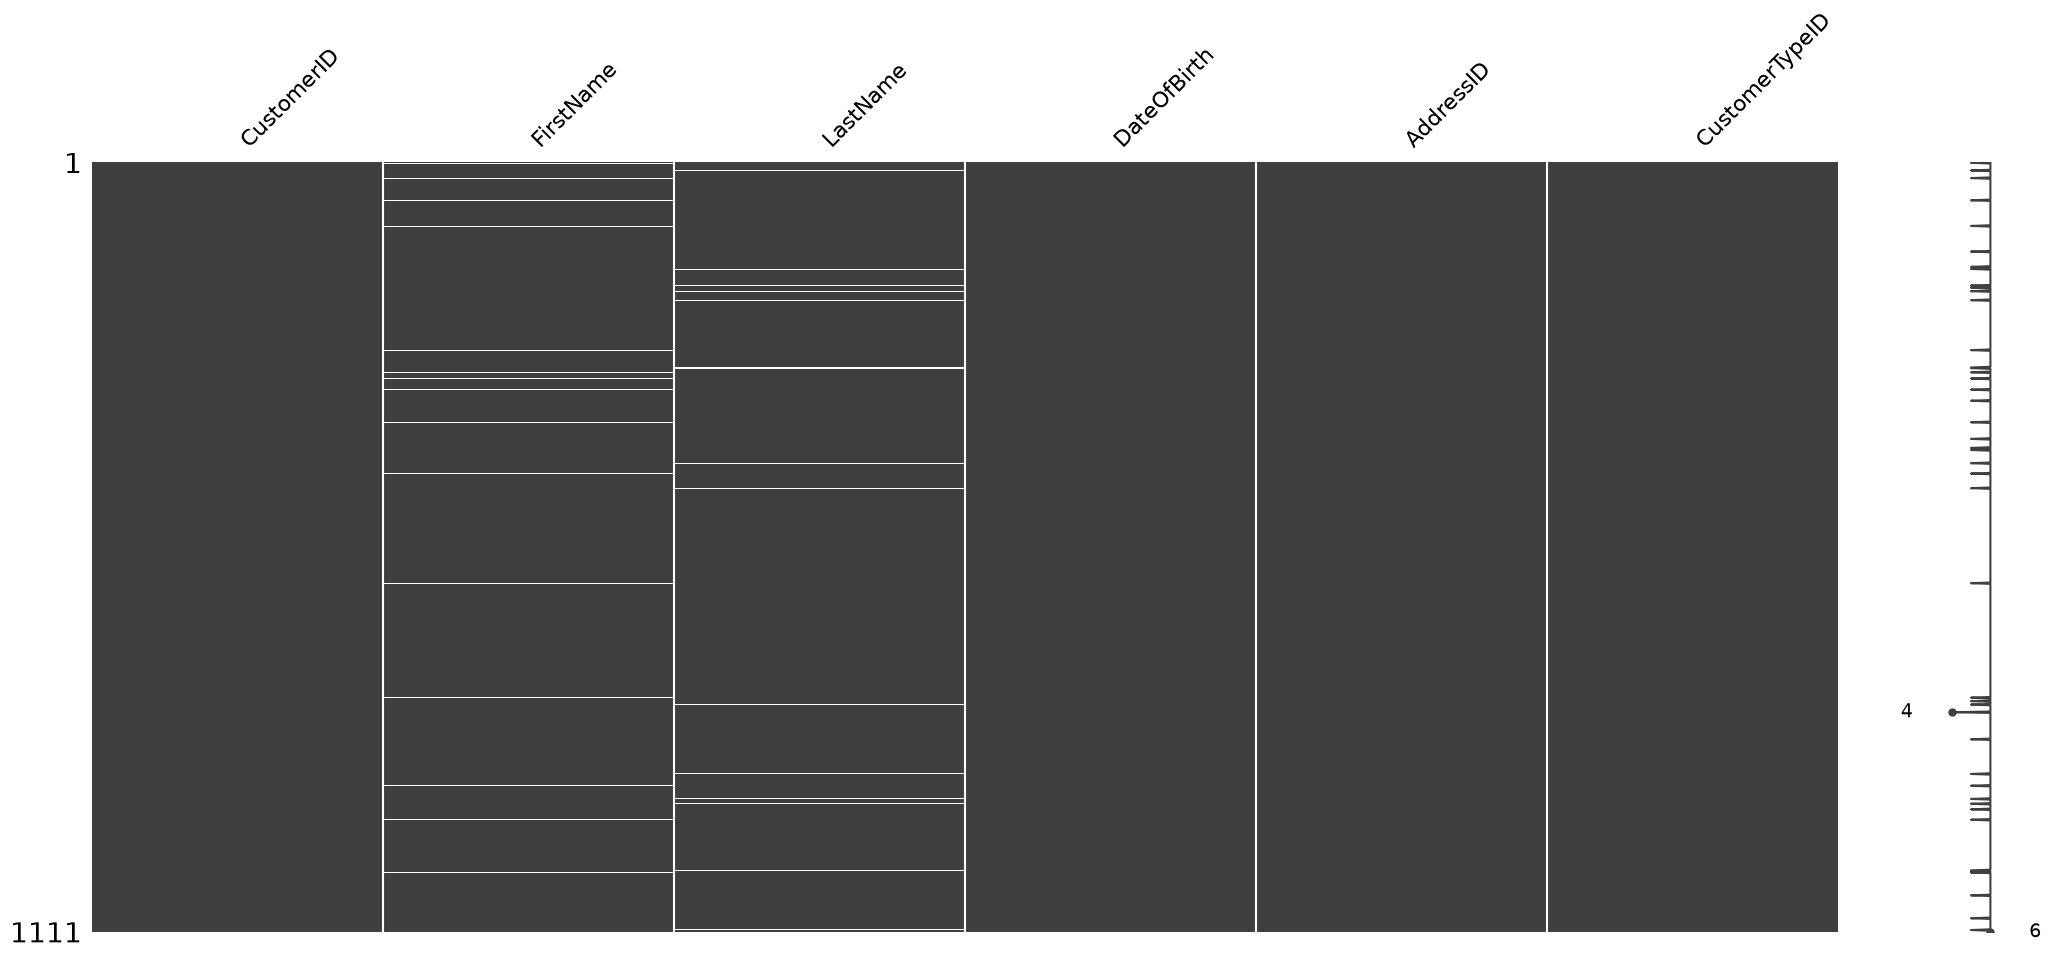

Accounts


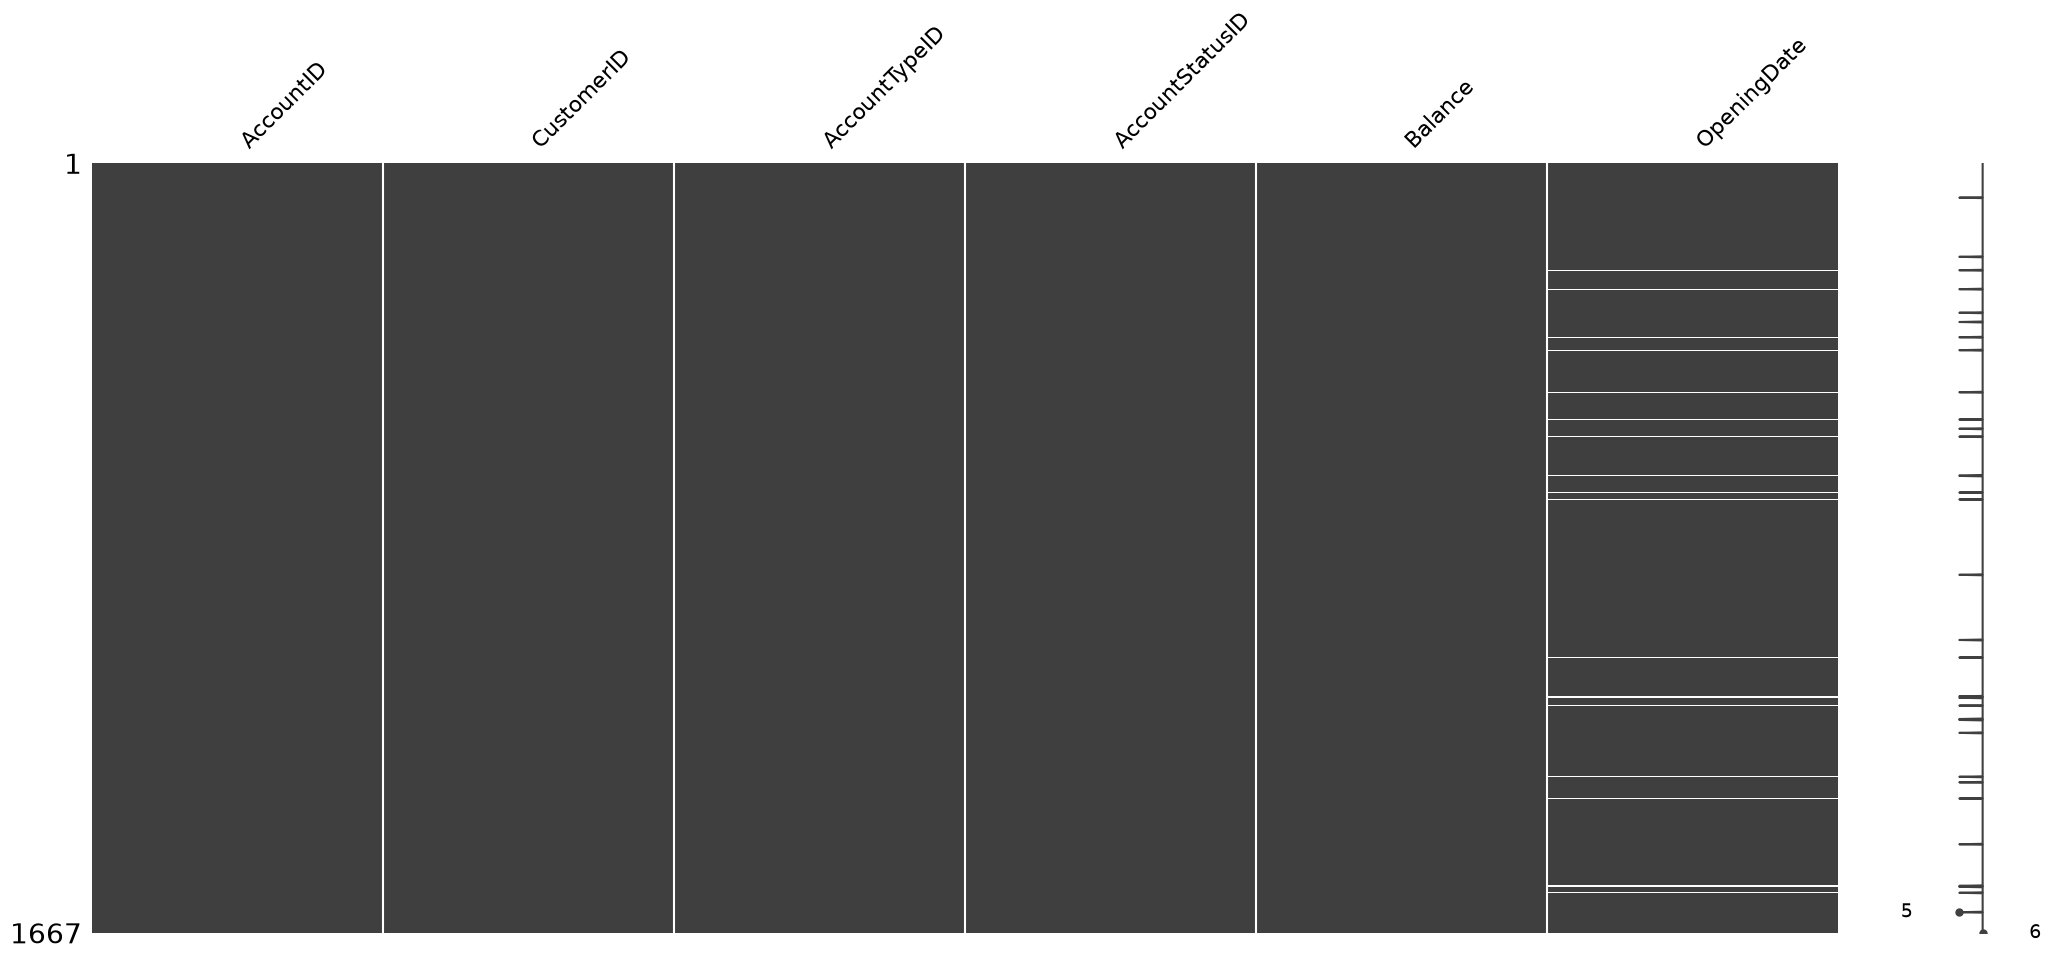

Transactions


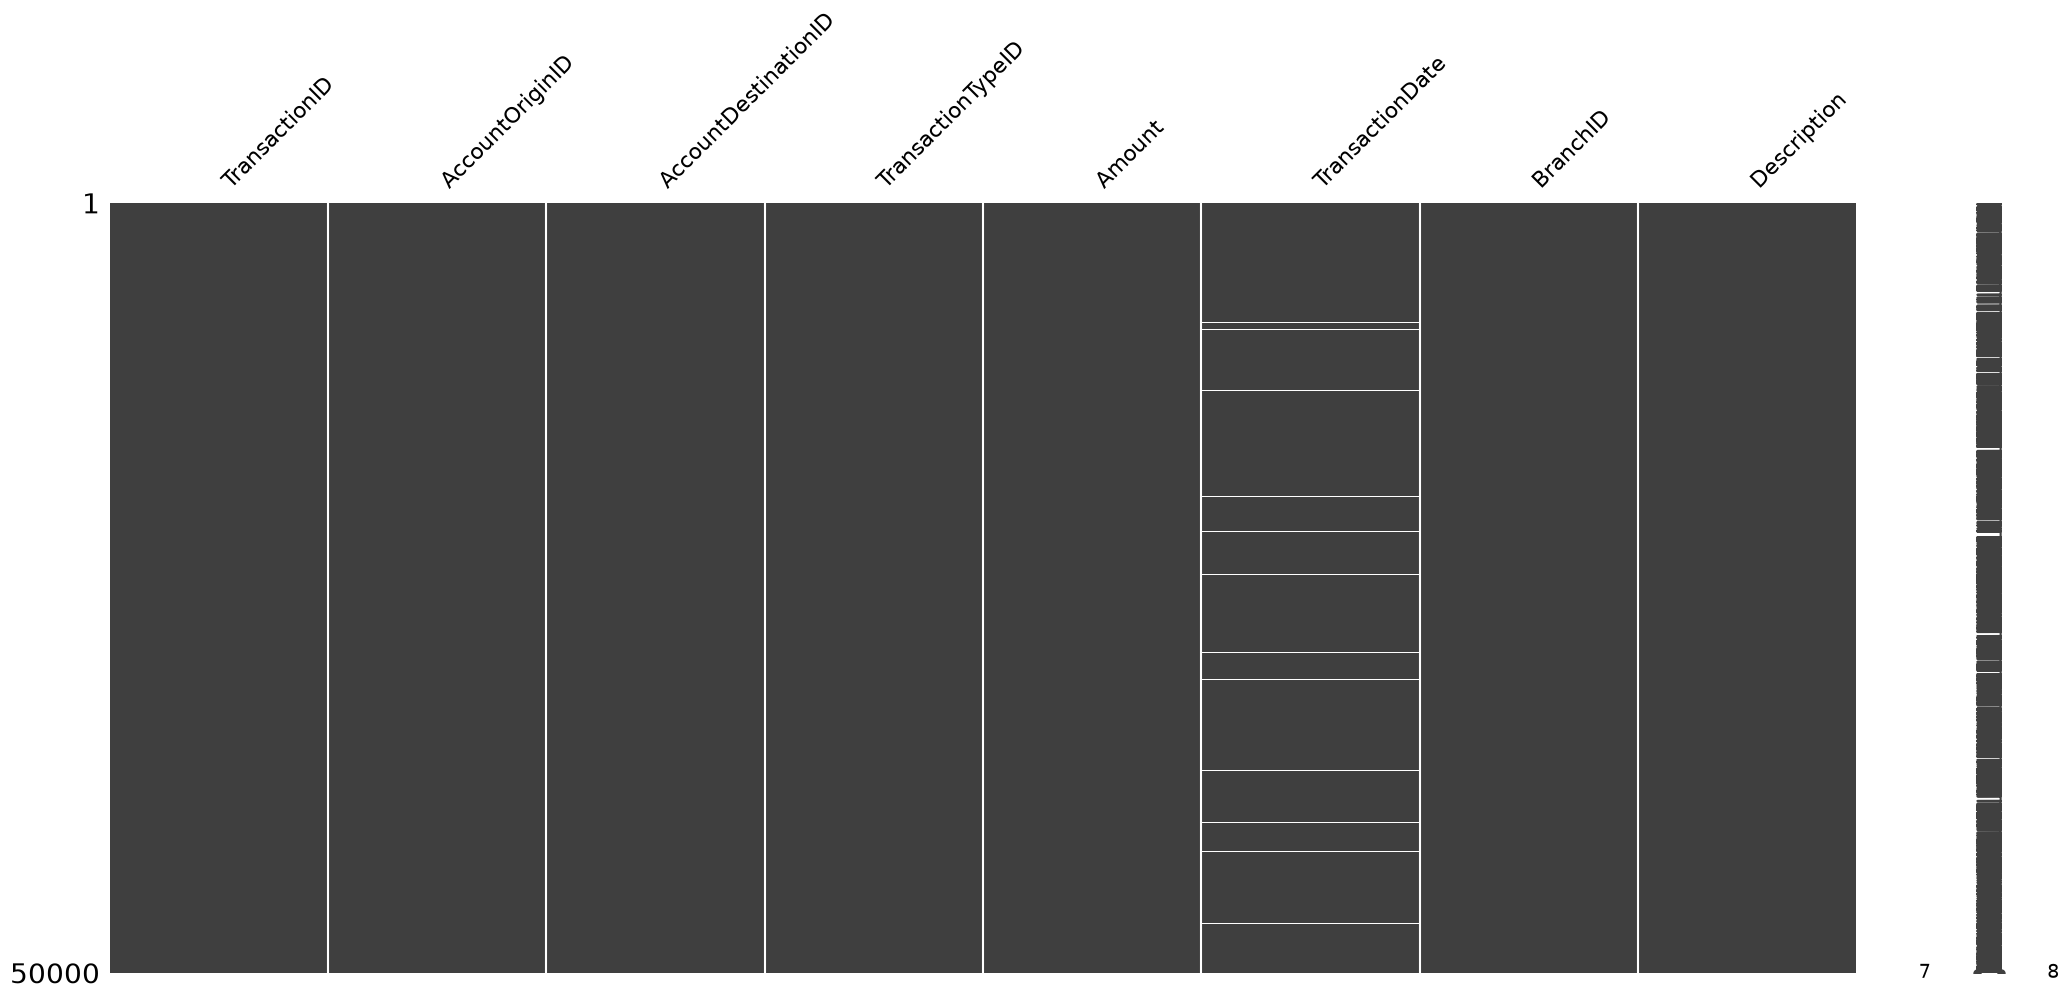

Loans


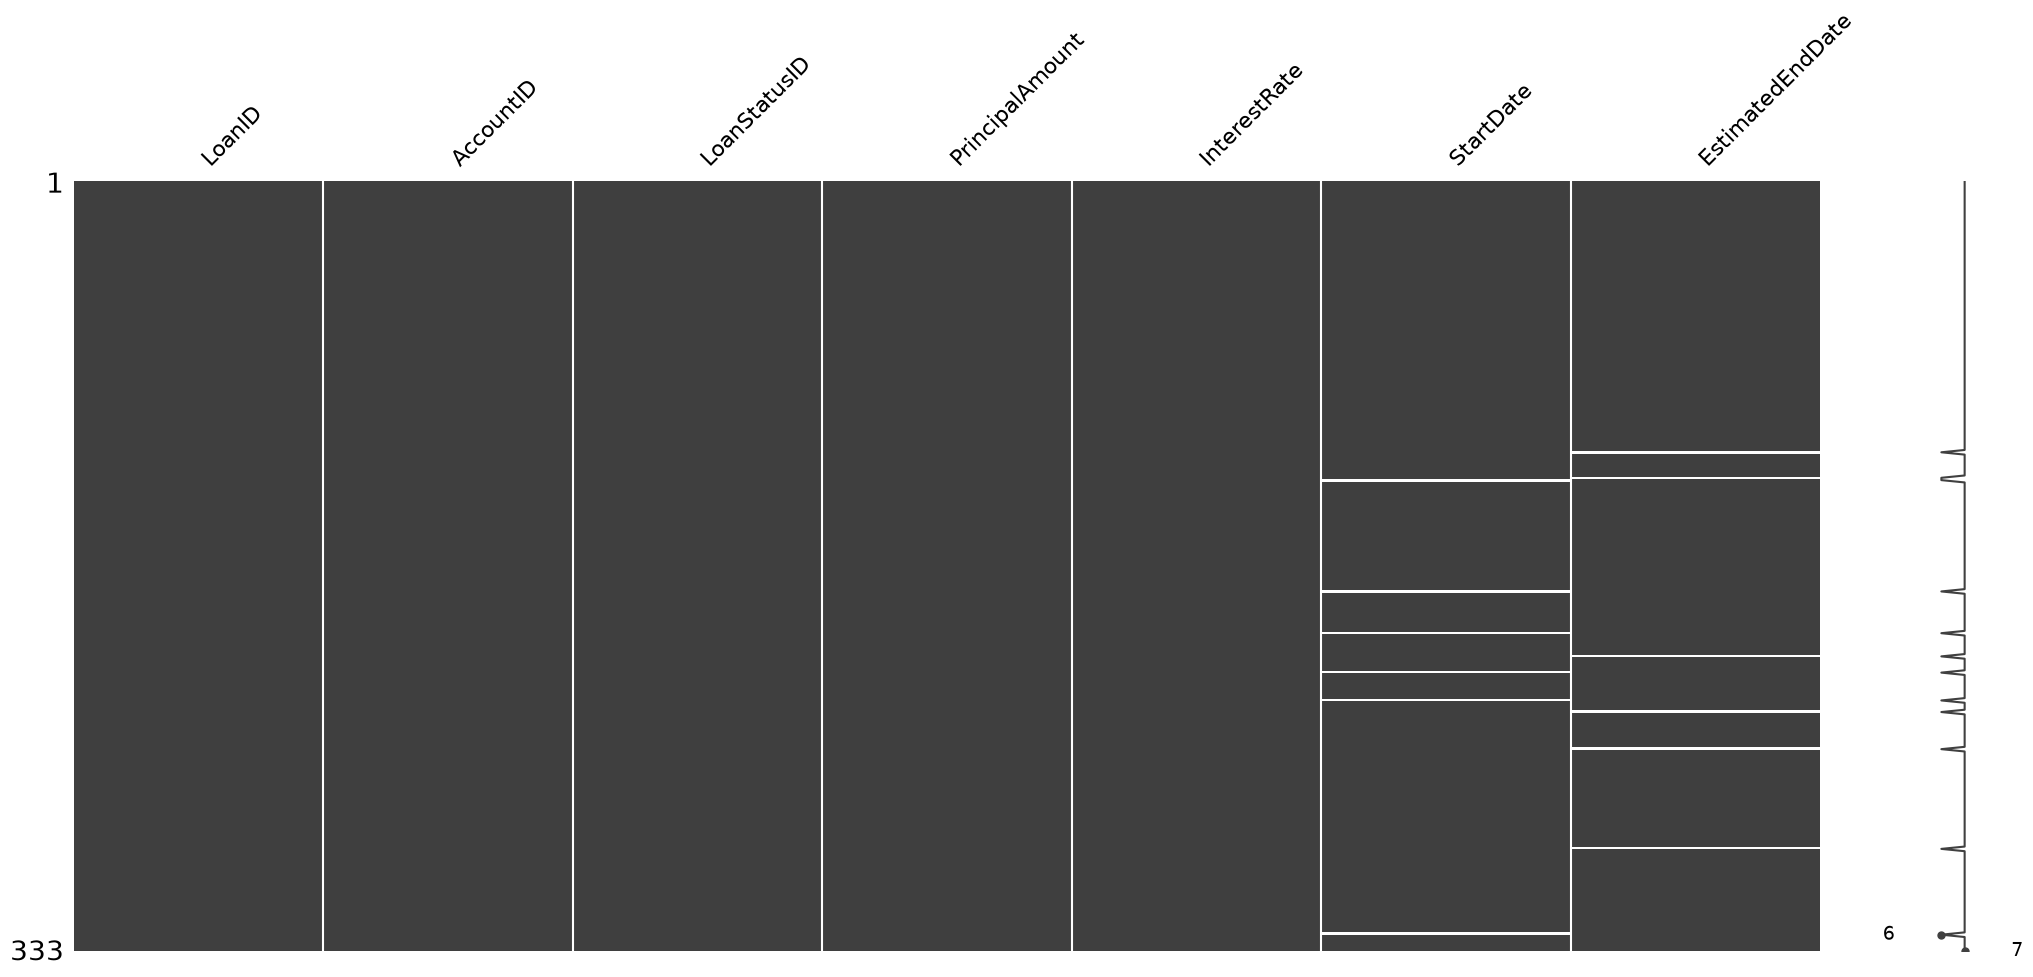

Branches


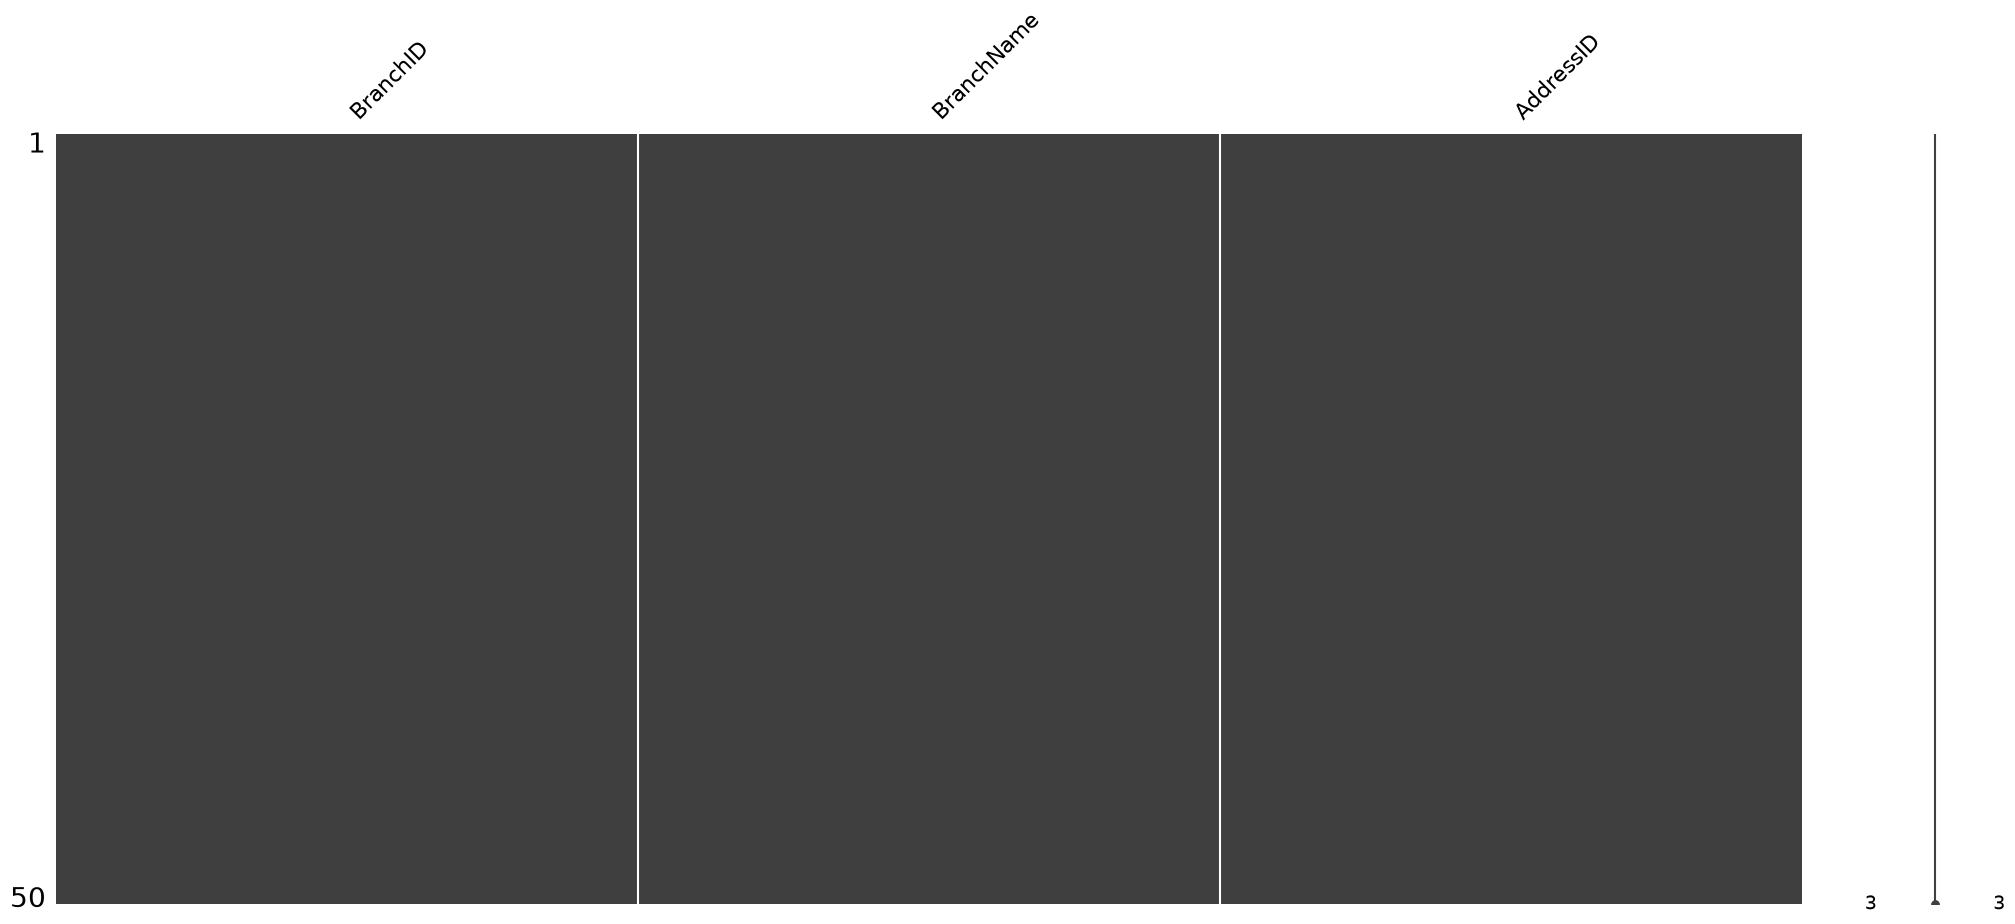

Addresses


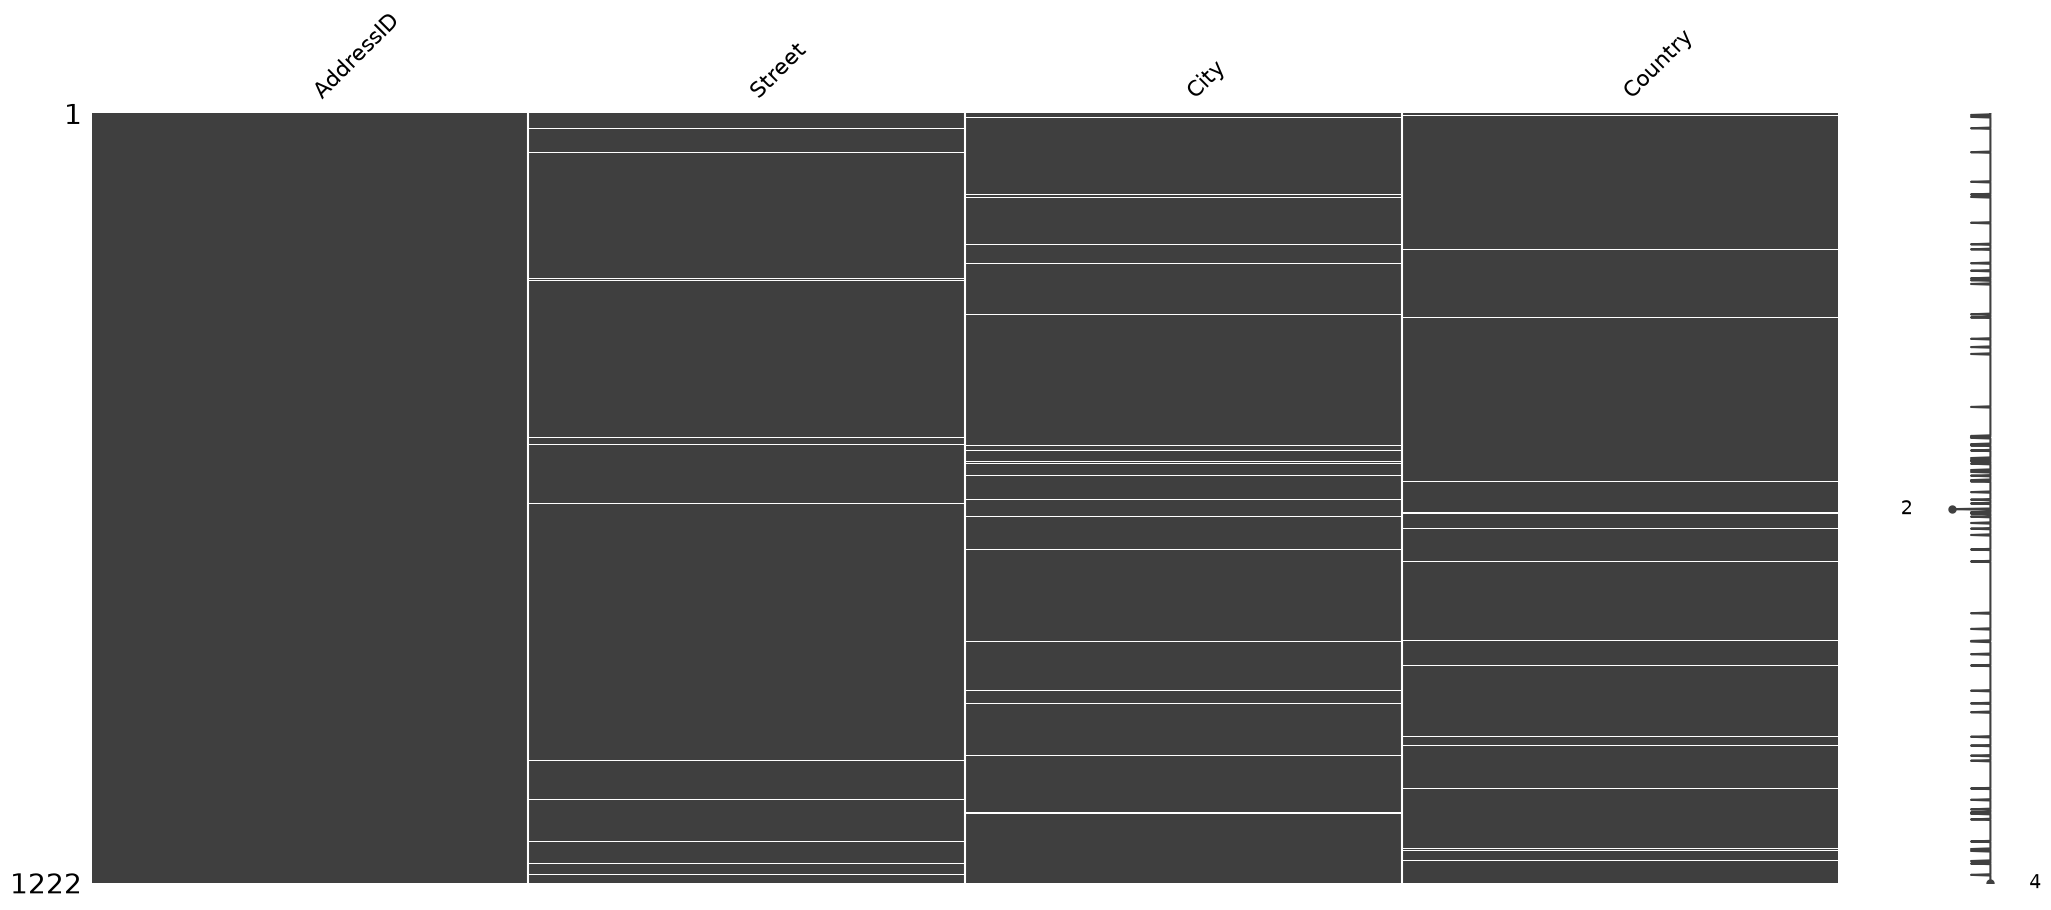

Account Types


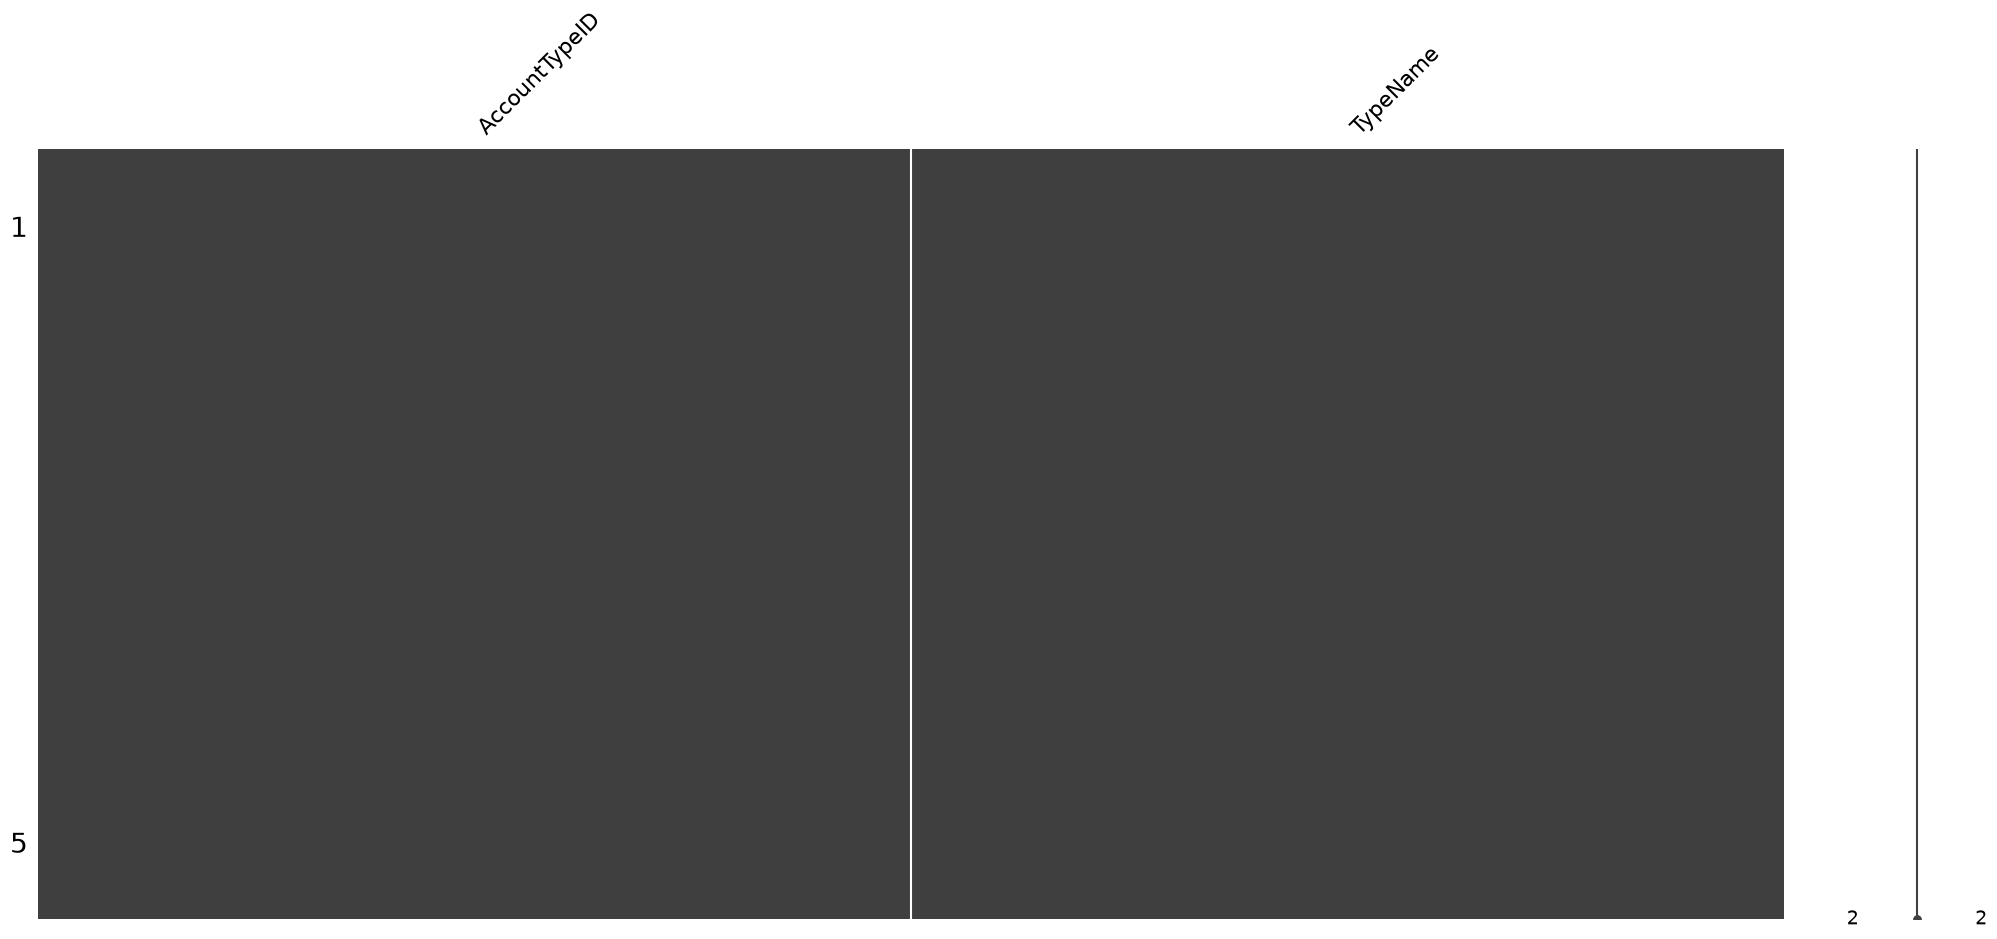

Account Status


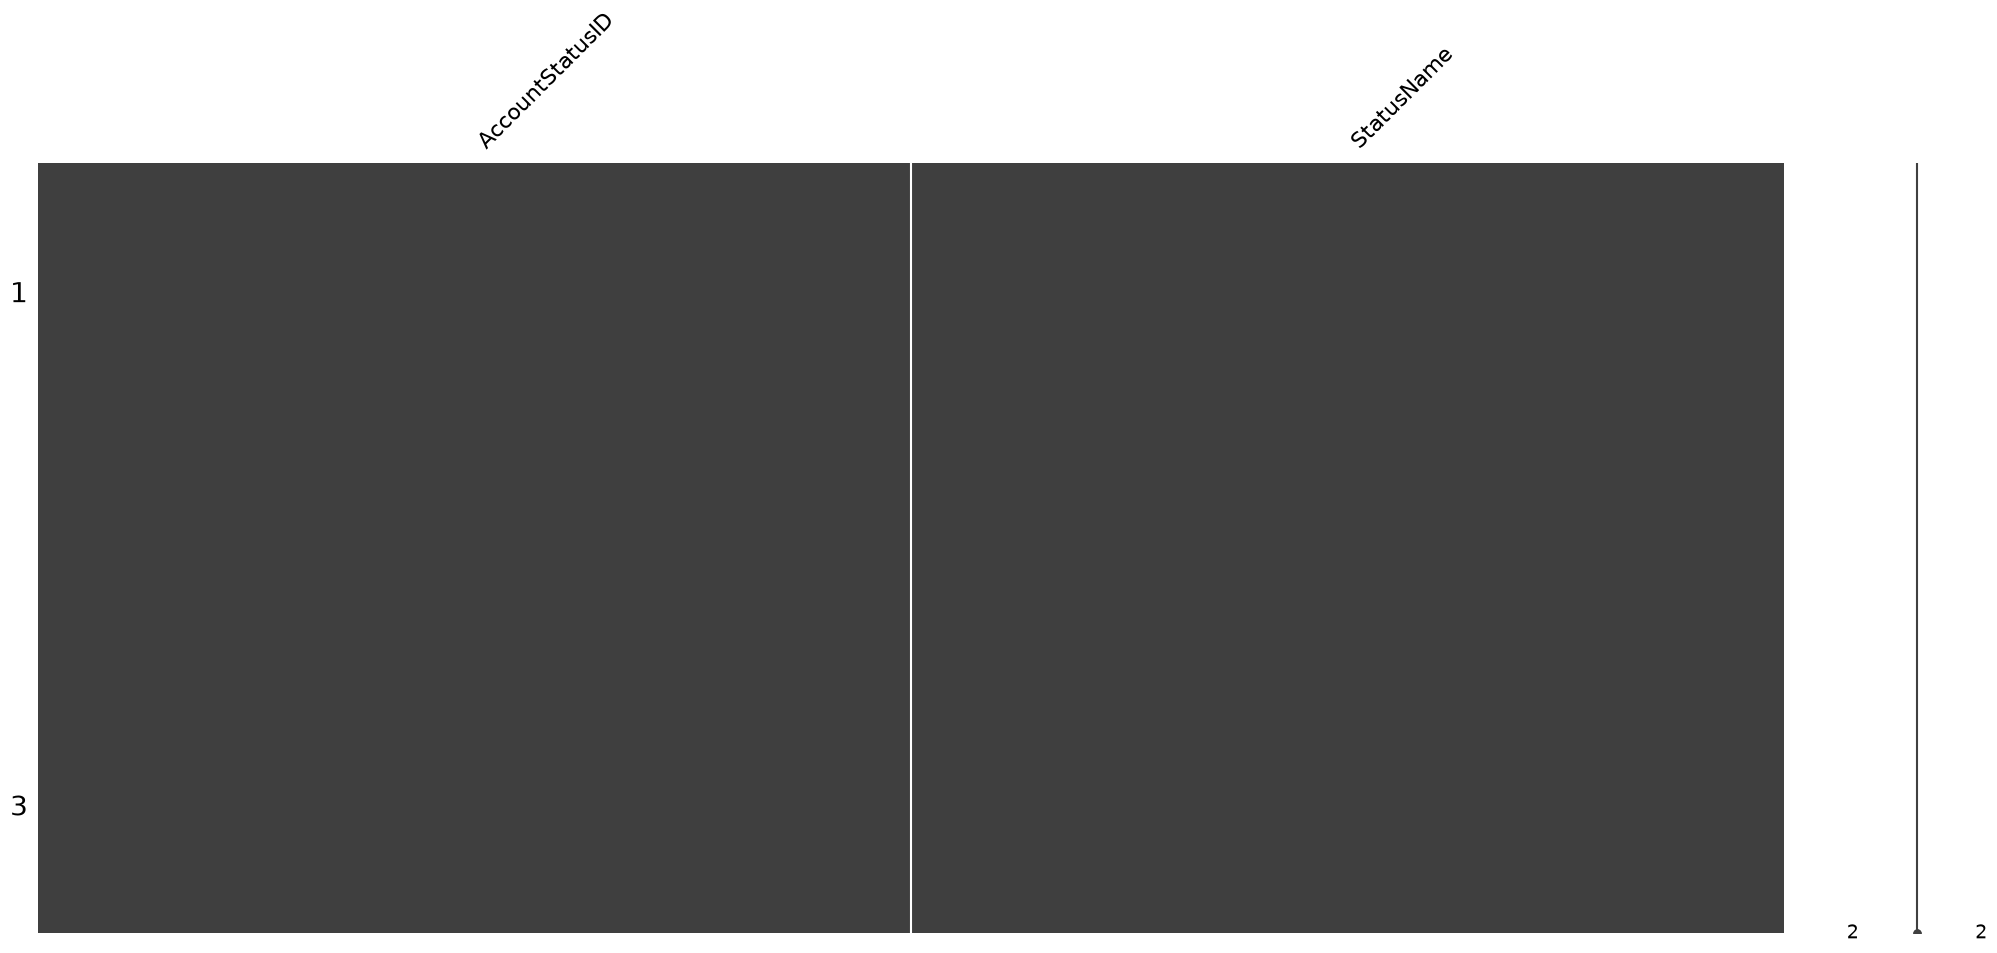

Customer Types


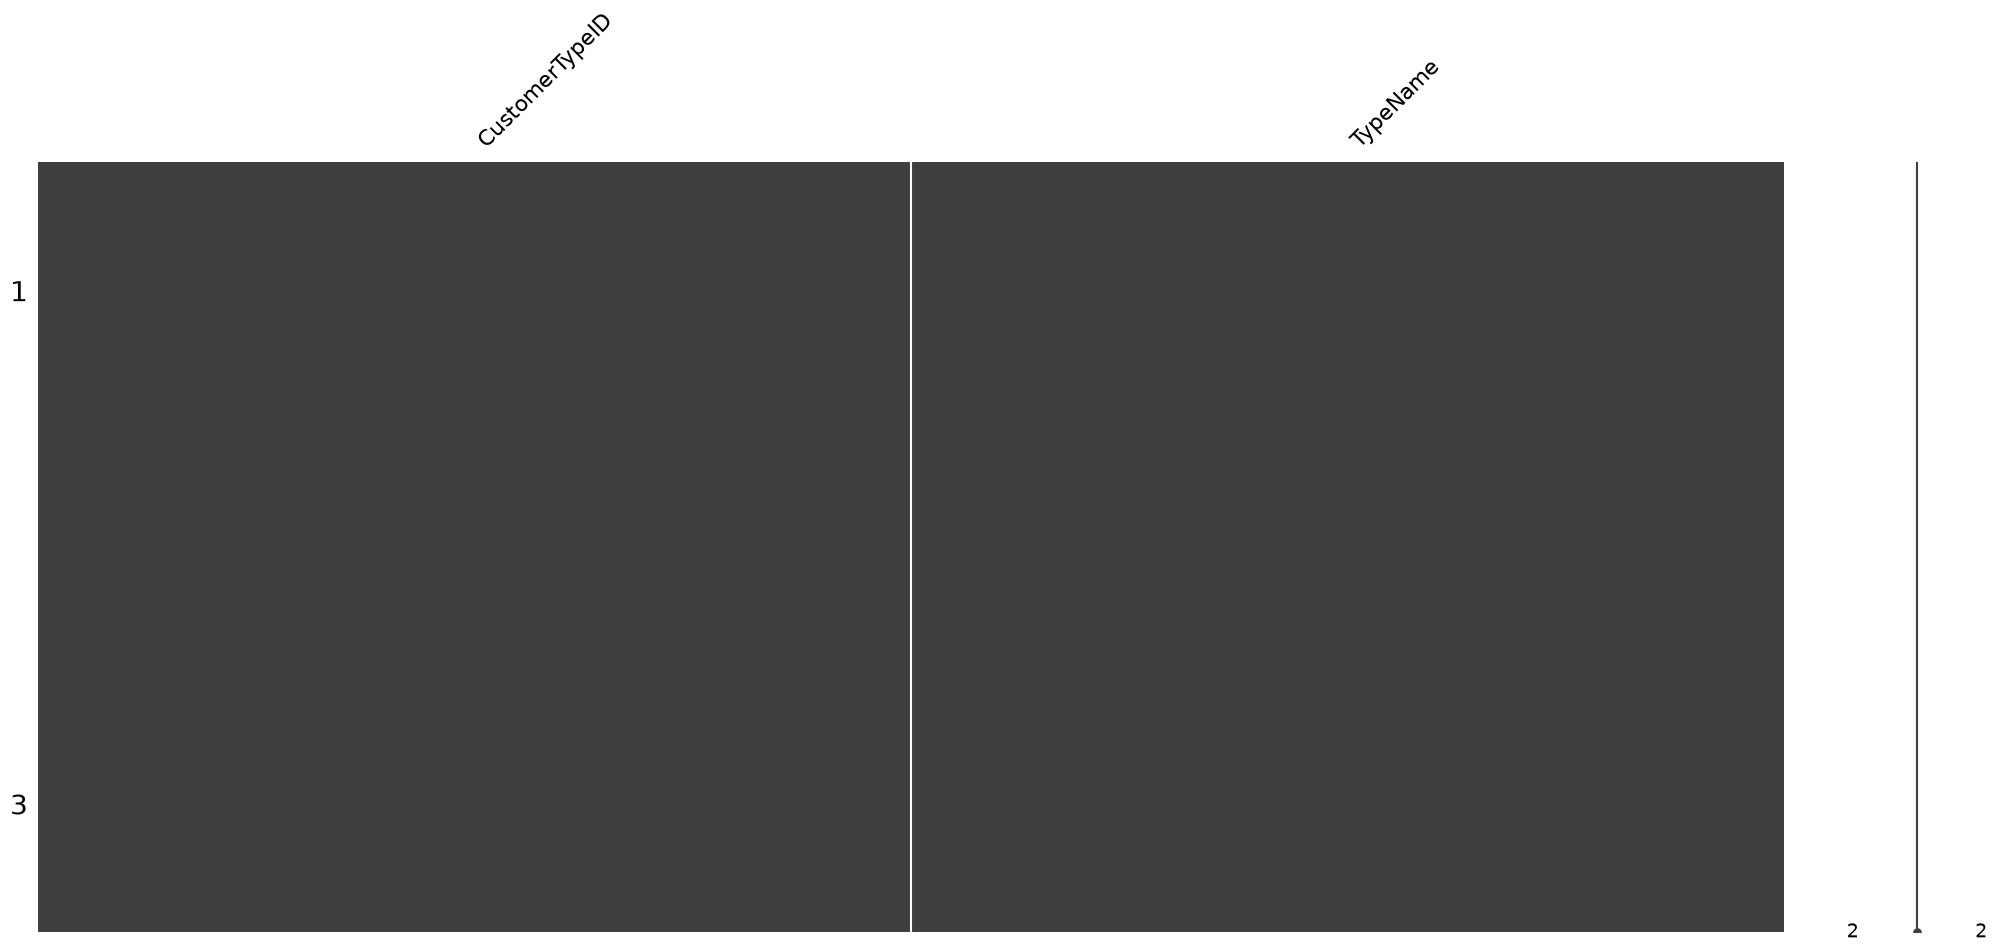

Loan Status


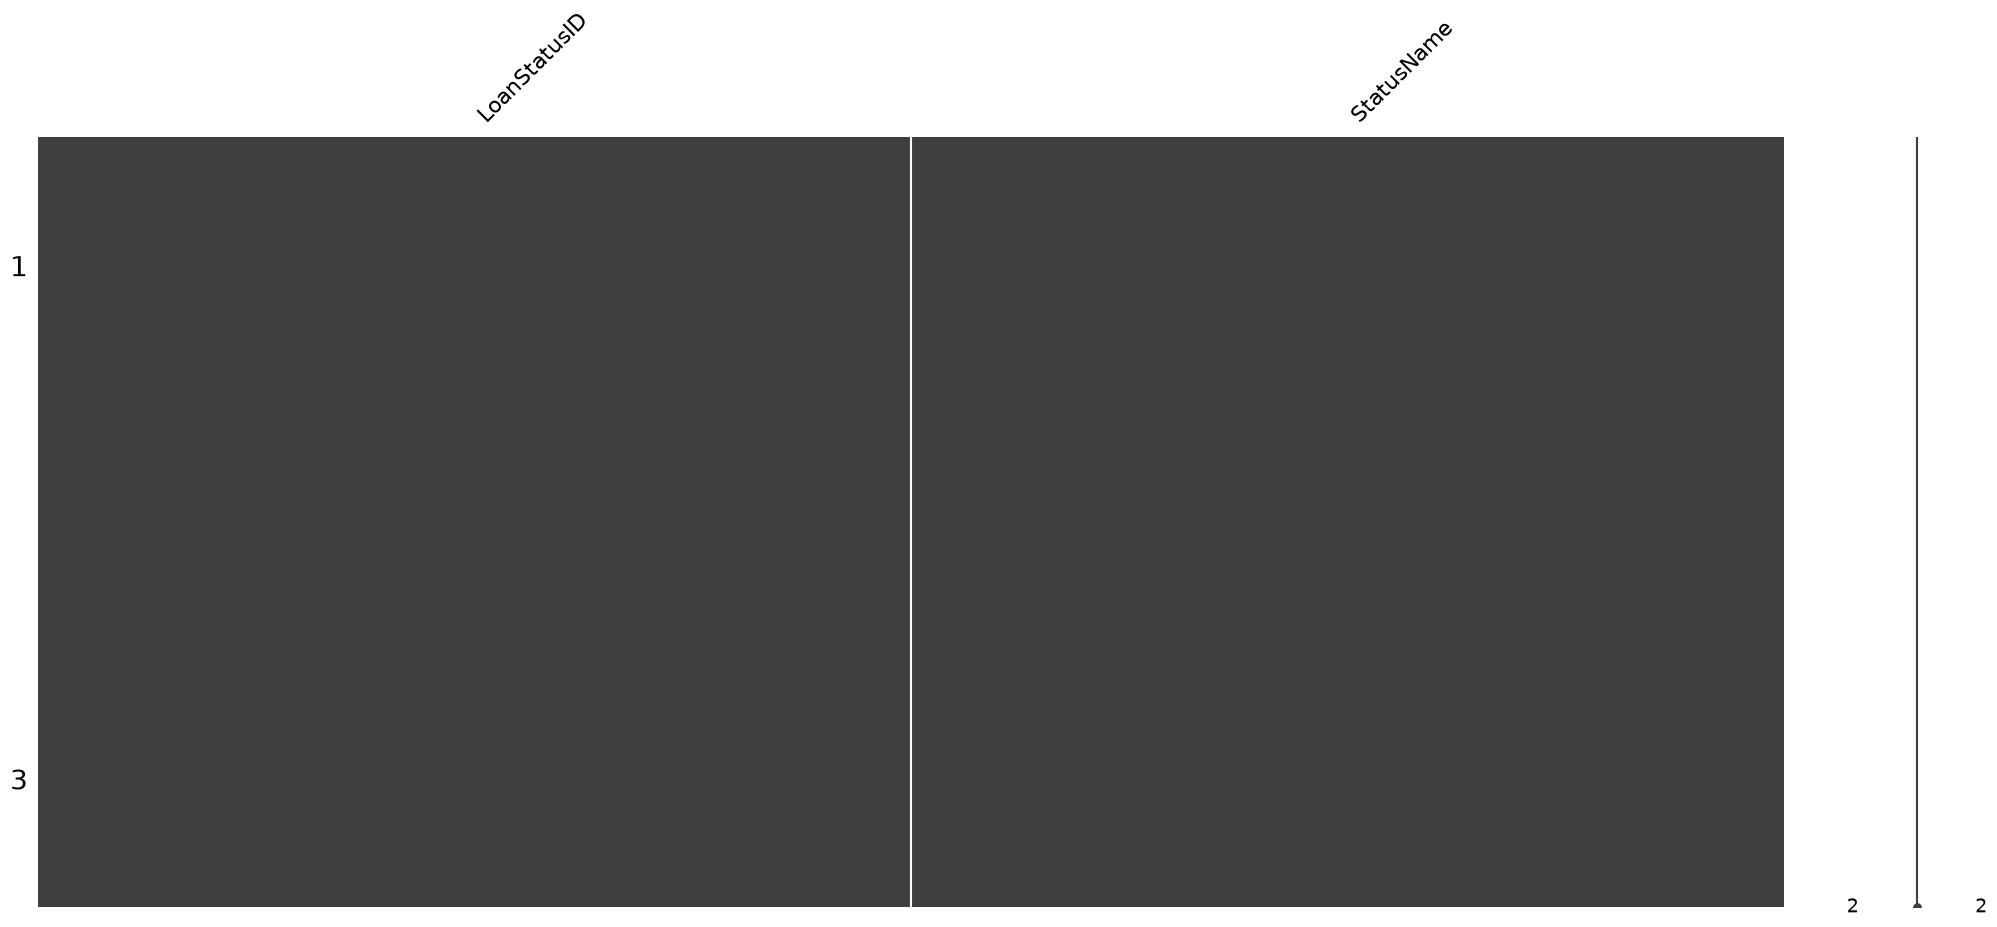

Transaction Types


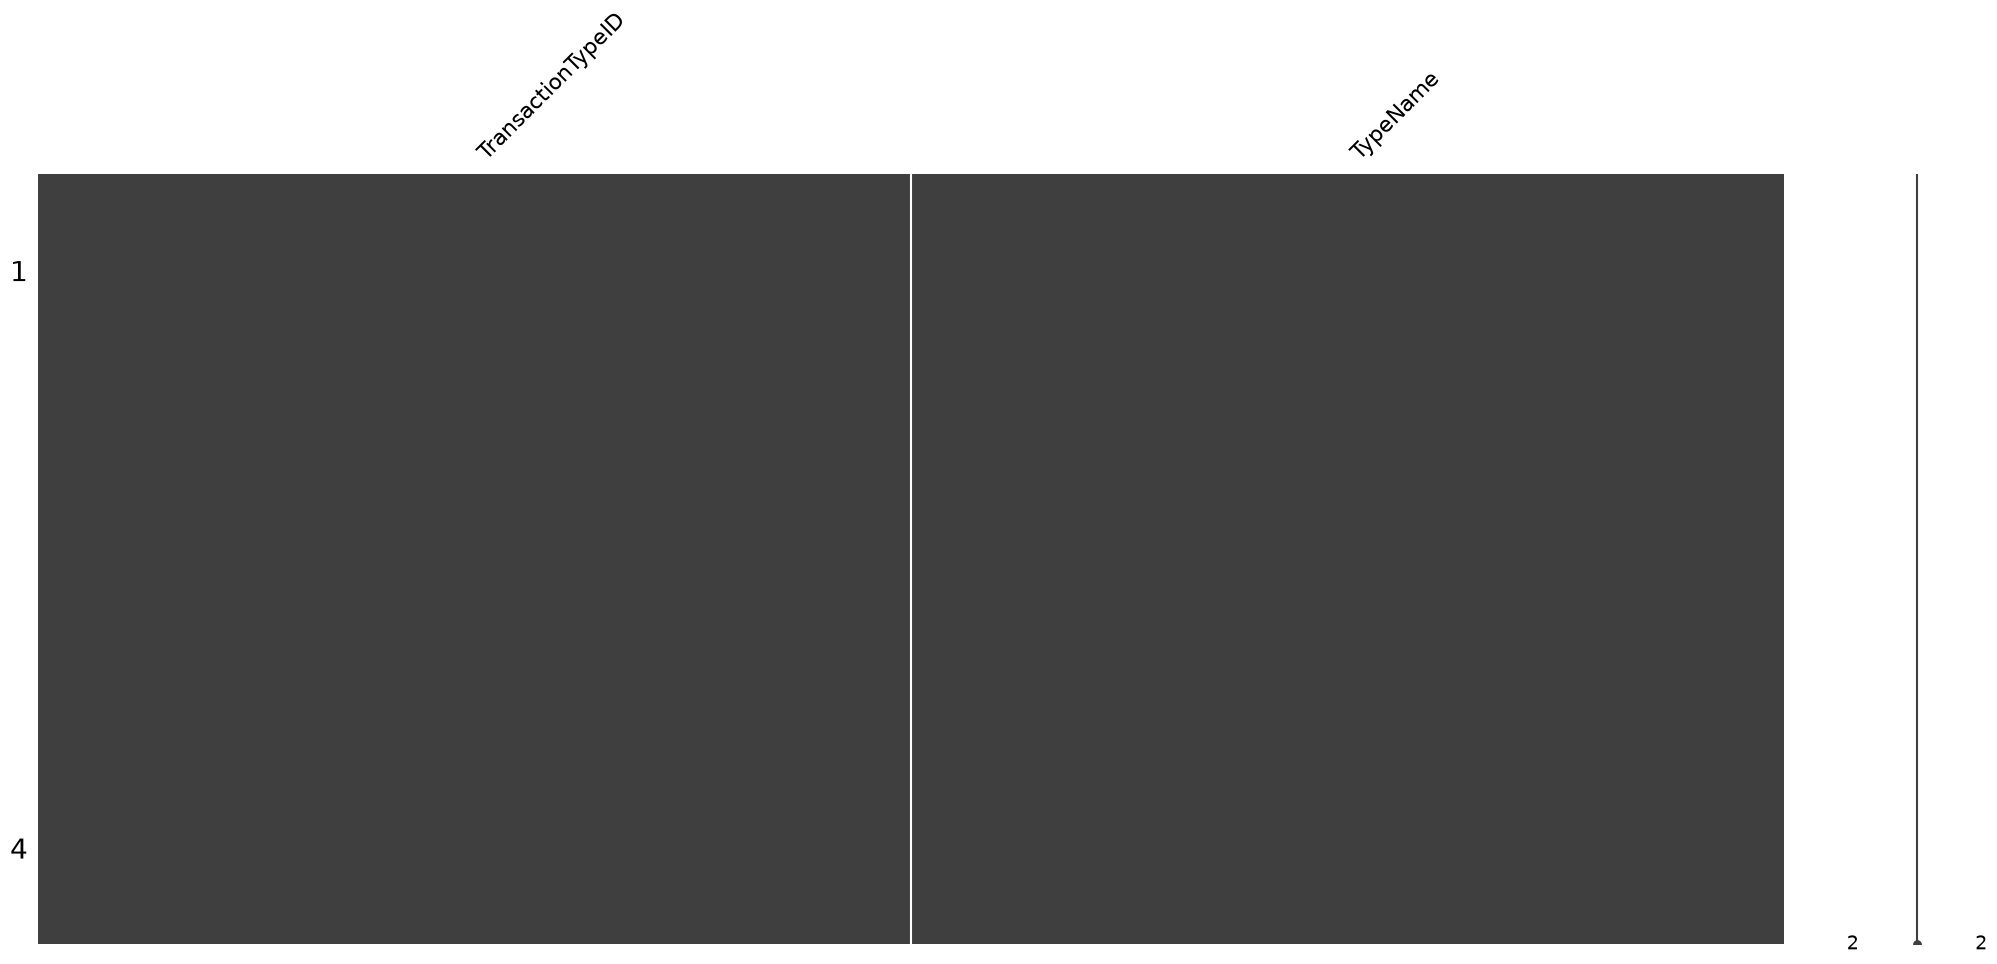

In [10]:
for name, df in datasets.items():

    print(name)
    print("="*80)
    msno.matrix(df)

    plt.show()

# Duplicate Record Analysis

In [11]:
duplicate_report = []

for name, df in datasets.items():

    duplicate_report.append({
        "Dataset": name,
        "Duplicate Rows": df.duplicated().sum()
    })

duplicate_report = pd.DataFrame(duplicate_report)

duplicate_report

,Dataset,Duplicate Rows
0,Customers,11
1,Accounts,16
2,Transactions,500
3,Loans,3
4,Branches,0
5,Addresses,12
6,Account Types,0
7,Account Status,0
8,Customer Types,0
9,Loan Status,0


# Data Quality Summary

In [12]:
quality = []

for name, df in datasets.items():

    quality.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

quality = pd.DataFrame(quality)

quality

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,1111,6,45,11
1,Accounts,1667,6,33,16
2,Transactions,50000,8,1000,500
3,Loans,333,7,12,3
4,Branches,50,3,0,0
5,Addresses,1222,4,74,12
6,Account Types,5,2,0,0
7,Account Status,3,2,0,0
8,Customer Types,3,2,0,0
9,Loan Status,3,2,0,0


# Data Dictionary

The following table describes the datasets used in this project.

In [13]:
dictionary = pd.DataFrame({

    "Dataset":[
        "Customers",
        "Accounts",
        "Transactions",
        "Loans",
        "Branches",
        "Addresses",
        "Account Types",
        "Account Statuses",
        "Customer Types",
        "Loan Statuses",
        "Transaction Types"
    ],

    "Purpose":[
        "Stores customer information",
        "Stores customer bank account information",
        "Stores transaction history",
        "Stores loan information",
        "Stores branch information",
        "Stores customer addresses",
        "Stores account type definitions",
        "Stores account status definitions",
        "Stores customer categories",
        "Stores loan status definitions",
        "Stores transaction type definitions"
    ]
})

dictionary

,Dataset,Purpose
0,Customers,Stores customer information
1,Accounts,Stores customer bank account information
2,Transactions,Stores transaction history
3,Loans,Stores loan information
4,Branches,Stores branch information
5,Addresses,Stores customer addresses
6,Account Types,Stores account type definitions
7,Account Statuses,Stores account status definitions
8,Customer Types,Stores customer categories
9,Loan Statuses,Stores loan status definitions


In [14]:
summary.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/dataset_summary.csv", index=False)

quality.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/data_quality_report.csv", index=False)

missing_report.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/missing_value_report.csv", index=False)

duplicate_report.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/duplicate_report.csv", index=False)

dictionary.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/data_dictionary.csv", index=False)

print("Reports Saved Successfully")

Reports Saved Successfully


# Module 1 Conclusion

This module successfully performed data understanding and exploratory profiling of the banking datasets.

Major activities completed include:

- Imported all required libraries.
- Loaded all banking datasets.
- Verified dataset dimensions.
- Examined data types.
- Identified missing values.
- Identified duplicate records.
- Generated dataset summary reports.
- Prepared the datasets for exploratory data analysis and machine learning.

The cleaned and profiled datasets will be used in subsequent modules such as customer segmentation, fraud detection, loan prediction, and sentiment analysis.

Module 1 - Phase 3: Exploratory Data Analysis (EDA)


The purpose of EDA is to:

Understand the data distribution.
Detect anomalies and outliers.
Identify relationships between variables.
Discover patterns and trends.
Generate business insights.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics of the banking datasets through statistical summaries and visualizations. This helps identify trends, anomalies, and data quality issues before machine learning.

In [15]:
# ==========================================================
# Visualization Settings
# ==========================================================

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["font.size"] = 11

print("Visualization environment ready.")

Visualization environment ready.


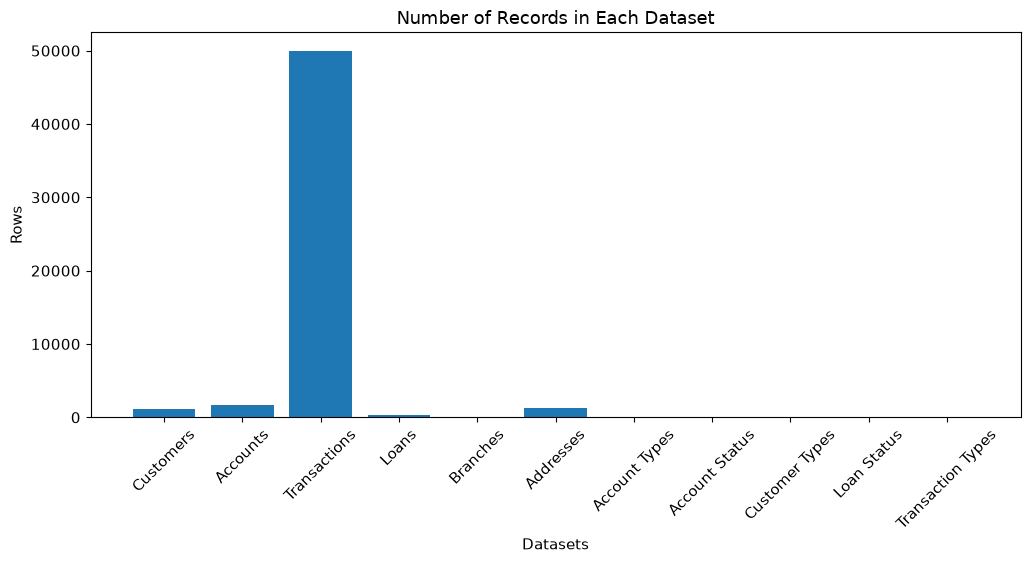

In [16]:
dataset_sizes = summary.copy()

plt.figure(figsize=(12,5))

plt.bar(dataset_sizes["Dataset"], dataset_sizes["Rows"])

plt.title("Number of Records in Each Dataset")

plt.xlabel("Datasets")

plt.ylabel("Rows")

plt.xticks(rotation=45)

plt.show()

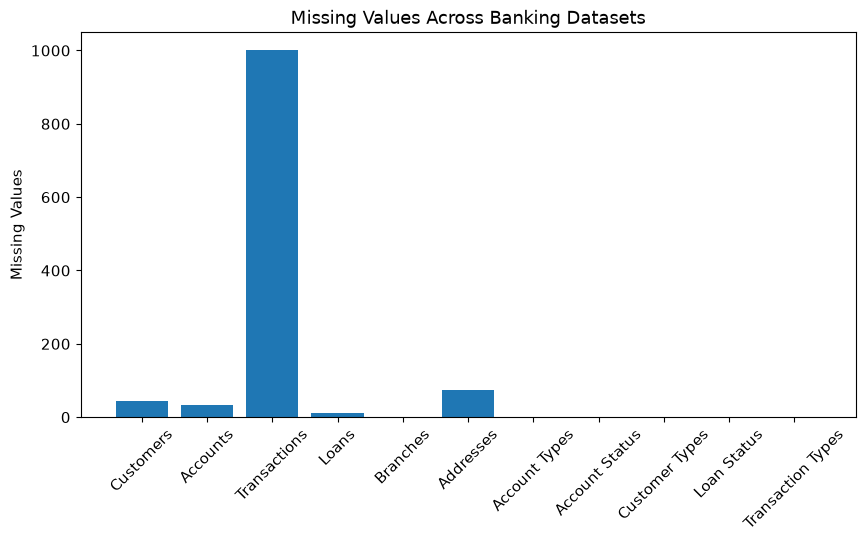

In [18]:
plt.figure(figsize=(10,5))

plt.bar(
    missing_report["Dataset"],
    missing_report["Total Missing Values"]
)

plt.xticks(rotation=45)

plt.ylabel("Missing Values")

plt.title("Missing Values Across Banking Datasets")

plt.show()

Text(0.5, 1.0, 'Duplicate Records')

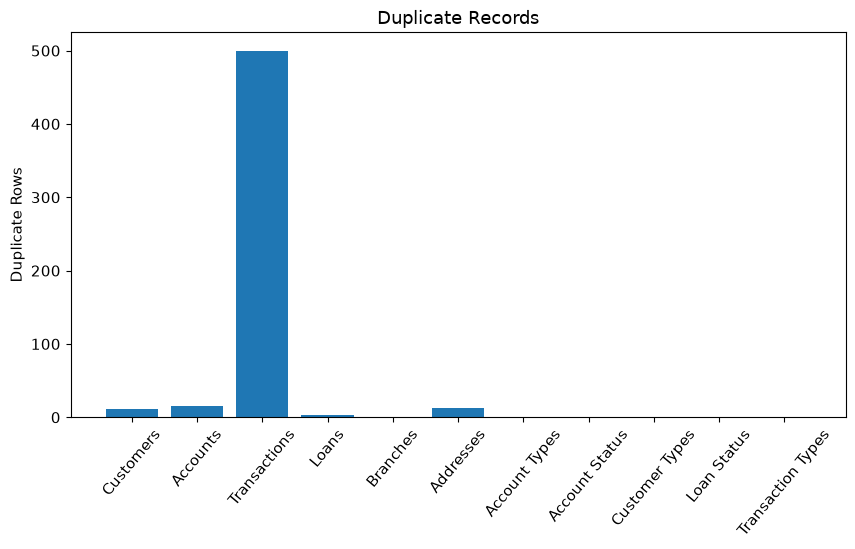

In [29]:
plt.figure(figsize=(10,5))

plt.bar(duplicate_report["Dataset"],duplicate_report["Duplicate Rows"])

plt.xticks(rotation=50)

plt.ylabel("Duplicate Rows")
plt.title("Duplicate Records")
           

Customers
    │
    ├── CustomerTypeID ─────────► Customer Types
    │
    ├── AddressID ──────────────► Addresses
    │
    └── CustomerID
           │
           ▼
       Accounts
           │
           ├── AccountTypeID ───► Account Types
           ├── AccountStatusID ─► Account Status
           │
           └── AccountID
                 │
                 ├──────────────► Loans
                 │
                 └──────────────► Transactions

# Data Integration

The banking information is distributed across multiple relational tables.
To perform efficient analysis and build machine learning models, the tables
are merged into a master analytical dataset using their primary and foreign keys.

In [32]:
for name,df in datasets.items():
    print(name,df.columns.tolist())


Customers ['CustomerID', 'FirstName', 'LastName', 'DateOfBirth', 'AddressID', 'CustomerTypeID']
Accounts ['AccountID', 'CustomerID', 'AccountTypeID', 'AccountStatusID', 'Balance', 'OpeningDate']
Transactions ['TransactionID', 'AccountOriginID', 'AccountDestinationID', 'TransactionTypeID', 'Amount', 'TransactionDate', 'BranchID', 'Description']
Loans ['LoanID', 'AccountID', 'LoanStatusID', 'PrincipalAmount', 'InterestRate', 'StartDate', 'EstimatedEndDate']
Branches ['BranchID', 'BranchName', 'AddressID']
Addresses ['AddressID', 'Street', 'City', 'Country']
Account Types ['AccountTypeID', 'TypeName']
Account Status ['AccountStatusID', 'StatusName']
Customer Types ['CustomerTypeID', 'TypeName']
Loan Status ['LoanStatusID', 'StatusName']
Transaction Types ['TransactionTypeID', 'TypeName']


In [37]:
print(addresses	)

      AddressID           Street             City        Country
0           706          Edgardo         Stafford  United States
1           969         Fernwood        Opelousas  United States
2           129      Double Rock        Claremore  United States
3           780             Avon   Universal City            NaN
4           652              Dow        Covington  United States
...         ...              ...              ...            ...
1217        936  Diamond Heights  West Des Moines  United States
1218        586           Prague        Milwaukie  United States
1219        559         Rousseau       Port Huron  United States
1220        207      Double Rock           Lenexa  United States
1221        646            Flood        Avon Lake  United States

[1222 rows x 4 columns]


In [38]:
master=customers.merge(addresses ,on="AddressID",how="left")

In [41]:
master=master.merge(customer_types,on="CustomerTypeID",how="left")

In [43]:
master=master.merge(accounts ,on="CustomerID",how="left")

In [45]:
master=master.merge(account_types,on="AccountTypeID",how="left")

In [48]:
master=master.merge(account_statuses,on="AccountStatusID",how="left")

In [49]:
master.head(5)

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,TypeName_x,AccountID,AccountTypeID,AccountStatusID,Balance,OpeningDate,TypeName_y,StatusName_x,StatusName_y
0,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1,Columbia Square,Aurora,United States,Individual,200833.0,2.0,1.0,94714.26,2021-05-25 00:00:00.000000,Savings,Active,Active
1,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1,Columbia Square,Aurora,United States,Individual,200904.0,4.0,1.0,84891.94,2021-12-12 00:00:00.000000,Business,Active,Active
2,10983,NaN,Battle,1963-02-01 00:00:00.000000,958,2,Coventry,Saco,United States,Small Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10837,Angelena,Harrington,1964-03-25 00:00:00.000000,86,3,Wilson,Carlsbad,United States,Large Enterprise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10107,Remona,Glass,1965-09-16 00:00:00.000000,595,1,Koret,Grapevine,United States,Individual,200191.0,2.0,1.0,64668.96,2021-04-07 00:00:00.000000,Savings,Active,Active


In [51]:
master.shape

(2001, 18)

In [52]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       2001 non-null   int64  
 1   FirstName        1970 non-null   str    
 2   LastName         1964 non-null   str    
 3   DateOfBirth      2001 non-null   str    
 4   AddressID        2001 non-null   int64  
 5   CustomerTypeID   2001 non-null   int64  
 6   Street           1970 non-null   str    
 7   City             1954 non-null   str    
 8   Country          1960 non-null   str    
 9   TypeName_x       2001 non-null   str    
 10  AccountID        1758 non-null   float64
 11  AccountTypeID    1758 non-null   float64
 12  AccountStatusID  1758 non-null   float64
 13  Balance          1758 non-null   float64
 14  OpeningDate      1722 non-null   str    
 15  TypeName_y       1758 non-null   str    
 16  StatusName_x     1758 non-null   str    
 17  StatusName_y     1758 non

In [53]:
master.describe(include="all")

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,TypeName_x,AccountID,AccountTypeID,AccountStatusID,Balance,OpeningDate,TypeName_y,StatusName_x,StatusName_y
count,2001.000000,1970,1964,2001,2001.000000,2001.000000,1970,1954,1960,2001,1758.000000,1758.000000,1758.000000,1758.000000,1722,1758,1758,1758
unique,NaN,911,680,1039,NaN,NaN,611,577,9,3,NaN,NaN,NaN,NaN,1000,5,3,3
top,NaN,Elfreda,Sheppard,NaT,NaN,NaN,Yorba,Zanesville,United States,Large Enterprise,NaN,NaN,NaN,NaN,2019-01-26 00:00:00.000000,Business,Active,Active
freq,NaN,20,20,38,NaN,NaN,32,32,1938,734,NaN,NaN,NaN,NaN,8,388,1414,1414
mean,10555.025487,NaN,NaN,NaN,631.184908,2.059970,NaN,NaN,NaN,NaN,200823.939135,3.040387,1.241752,48894.430950,NaN,NaN,NaN,NaN
std,317.230799,NaN,NaN,NaN,344.491448,0.818781,NaN,NaN,NaN,NaN,477.071797,1.406168,0.524990,29192.460219,NaN,NaN,NaN,NaN
min,10000.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,200000.000000,1.000000,1.000000,-486.680000,NaN,NaN,NaN,NaN
25%,10288.000000,NaN,NaN,NaN,340.000000,1.000000,NaN,NaN,NaN,NaN,200414.250000,2.000000,1.000000,23239.715000,NaN,NaN,NaN,NaN
50%,10553.000000,NaN,NaN,NaN,640.000000,2.000000,NaN,NaN,NaN,NaN,200817.500000,3.000000,1.000000,48937.705000,NaN,NaN,NaN,NaN
75%,10833.000000,NaN,NaN,NaN,927.000000,3.000000,NaN,NaN,NaN,NaN,201236.750000,4.000000,1.000000,74642.982500,NaN,NaN,NaN,NaN


In [54]:
master.rename(columns={"TypeName_x":"CustomerType",
    "TypeName_y":"AccountType",
    "StatusName":"AccountStatus"},inplace=True)

In [56]:
master.columns.tolist()

['CustomerID',
 'FirstName',
 'LastName',
 'DateOfBirth',
 'AddressID',
 'CustomerTypeID',
 'Street',
 'City',
 'Country',
 'CustomerType',
 'AccountID',
 'AccountTypeID',
 'AccountStatusID',
 'Balance',
 'OpeningDate',
 'AccountType',
 'StatusName_x',
 'StatusName_y']

In [57]:
master.rename(columns={
    "StatusName_x": "AccountStatus",
    "StatusName_y": "LoanStatus"
}, inplace=True)

master.columns

Index(['CustomerID', 'FirstName', 'LastName', 'DateOfBirth', 'AddressID',
       'CustomerTypeID', 'Street', 'City', 'Country', 'CustomerType',
       'AccountID', 'AccountTypeID', 'AccountStatusID', 'Balance',
       'OpeningDate', 'AccountType', 'AccountStatus', 'LoanStatus'],
      dtype='str')

In [61]:
master.to_csv(
    "/mnt/Project/mlm/AI_Banking_Financial_Intelligence/datasets/processed_data/master_dataset.csv",
    index=False
)

print("Master dataset saved successfully!")

Master dataset saved successfully!


In [62]:
master.head(5)

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,CustomerType,AccountID,AccountTypeID,AccountStatusID,Balance,OpeningDate,AccountType,AccountStatus,LoanStatus
0,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1,Columbia Square,Aurora,United States,Individual,200833.0,2.0,1.0,94714.26,2021-05-25 00:00:00.000000,Savings,Active,Active
1,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1,Columbia Square,Aurora,United States,Individual,200904.0,4.0,1.0,84891.94,2021-12-12 00:00:00.000000,Business,Active,Active
2,10983,NaN,Battle,1963-02-01 00:00:00.000000,958,2,Coventry,Saco,United States,Small Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10837,Angelena,Harrington,1964-03-25 00:00:00.000000,86,3,Wilson,Carlsbad,United States,Large Enterprise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10107,Remona,Glass,1965-09-16 00:00:00.000000,595,1,Koret,Grapevine,United States,Individual,200191.0,2.0,1.0,64668.96,2021-04-07 00:00:00.000000,Savings,Active,Active


In [64]:
master.isnull().sum().sort_values(ascending=False)

OpeningDate        279
LoanStatus         243
AccountTypeID      243
AccountStatusID    243
AccountType        243
AccountStatus      243
AccountID          243
Balance            243
City                47
Country             41
LastName            37
FirstName           31
Street              31
CustomerID           0
CustomerType         0
DateOfBirth          0
AddressID            0
CustomerTypeID       0
dtype: int64

In [65]:
master.describe()

,CustomerID,AddressID,CustomerTypeID,AccountID,AccountTypeID,AccountStatusID,Balance
count,2001.000000,2001.000000,2001.000000,1758.000000,1758.000000,1758.000000,1758.000000
mean,10555.025487,631.184908,2.059970,200823.939135,3.040387,1.241752,48894.430950
std,317.230799,344.491448,0.818781,477.071797,1.406168,0.524990,29192.460219
min,10000.000000,1.000000,1.000000,200000.000000,1.000000,1.000000,-486.680000
25%,10288.000000,340.000000,1.000000,200414.250000,2.000000,1.000000,23239.715000
50%,10553.000000,640.000000,2.000000,200817.500000,3.000000,1.000000,48937.705000
75%,10833.000000,927.000000,3.000000,201236.750000,4.000000,1.000000,74642.982500
max,11099.000000,1210.000000,3.000000,201650.000000,5.000000,3.000000,99828.980000


In [66]:
master.describe(include="object")

,FirstName,LastName,DateOfBirth,Street,City,Country,CustomerType,OpeningDate,AccountType,AccountStatus,LoanStatus
count,1970,1964,2001,1970,1954,1960,2001,1722,1758,1758,1758
unique,911,680,1039,611,577,9,3,1000,5,3,3
top,Elfreda,Sheppard,NaT,Yorba,Zanesville,United States,Large Enterprise,2019-01-26 00:00:00.000000,Business,Active,Active
freq,20,20,38,32,32,1938,734,8,388,1414,1414


Customer Type Distribution


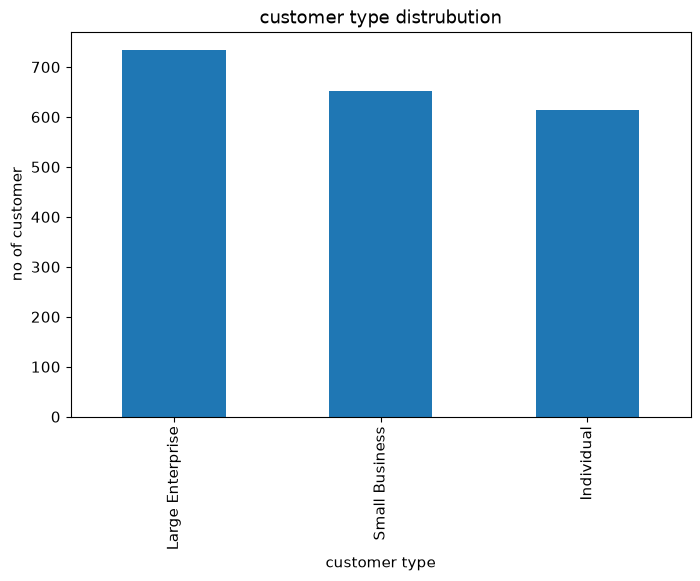

In [126]:
plt.figure(figsize=(8,5))

master["CustomerType"].value_counts().plot(kind="bar")
plt.xlabel("customer type")
plt.ylabel("no of customer")
plt.title("customer type distrubution")

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/customer_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

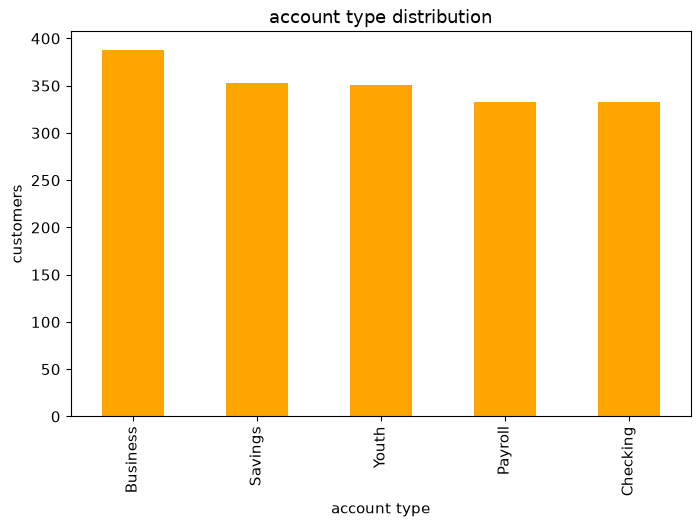

<Figure size 1000x500 with 0 Axes>

In [127]:
plt.figure(figsize=(8,5))

master["AccountType"].value_counts().plot(kind="bar",color="orange")

plt.xlabel("account type")
plt.ylabel("customers")
plt.title("account type distribution")
plt.show()
plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/account_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

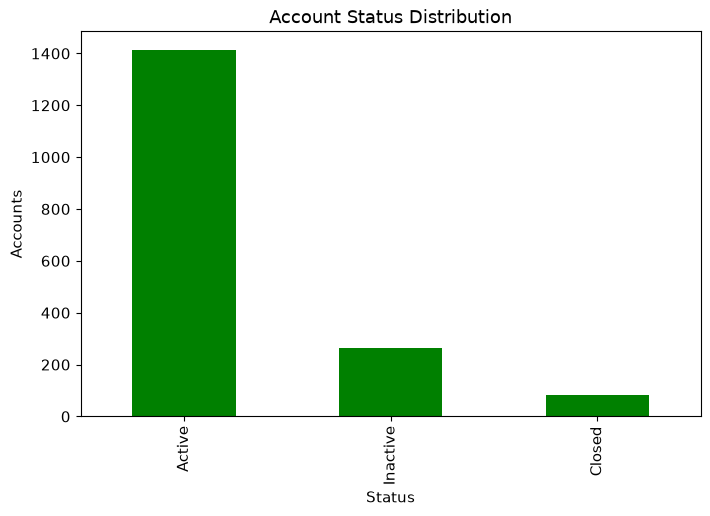

In [128]:
plt.figure(figsize=(8,5))

master["AccountStatus"].value_counts().plot(
    kind="bar",
    color="green"
)

plt.title("Account Status Distribution")
plt.xlabel("Status")
plt.ylabel("Accounts")
plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/account_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


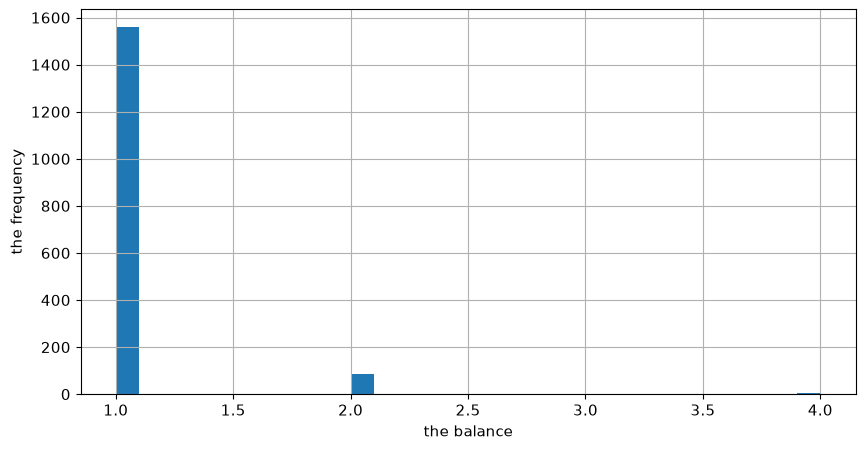

<Figure size 1000x500 with 0 Axes>

In [129]:
plt.figure(figsize=(10,5))

master["Balance"].value_counts().hist(bins=30)
plt.xlabel("the balance")
plt.ylabel("the frequency")
plt.show()
plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/balance_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

In [97]:
master["City"].unique()

<StringArray>
[        'Aurora',           'Saco',       'Carlsbad',      'Grapevine',
      'Opelousas',         'Garner',       'Westmont',       'Oak Lawn',
              nan,          'Selma',
 ...
 'Eagle Mountain',         'Edmond',       'Hartford',         'Duarte',
       'Ferndale',    'Thomasville',  'Warner Robins',      'Henderson',
     'San Angelo', 'Bonita Springs']
Length: 578, dtype: str

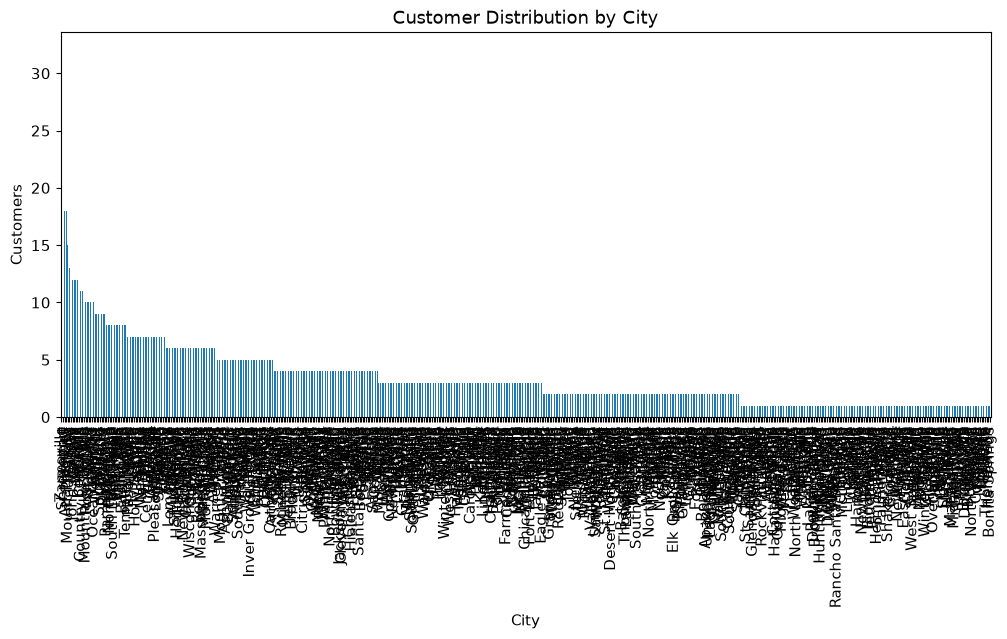

In [131]:
plt.figure(figsize=(12,5))

master["City"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Customers")

plt.xticks(rotation=90)

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/customer_distribution_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

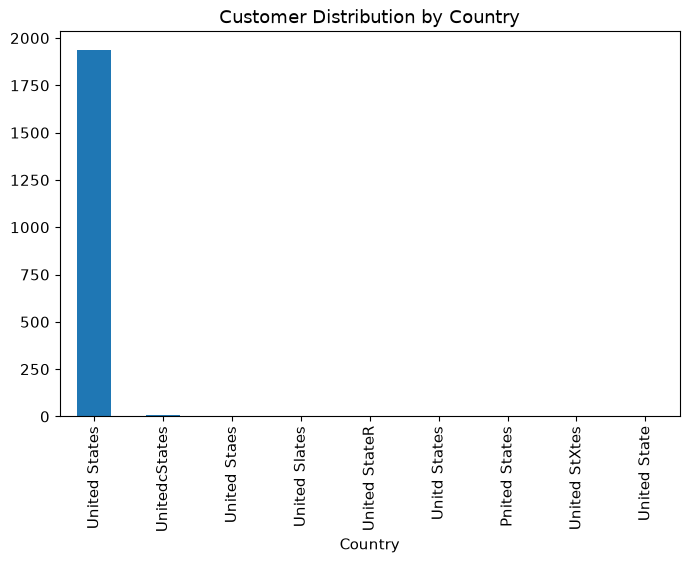

In [100]:
plt.figure(figsize=(8,5))

master["Country"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Distribution by Country")

plt.show()

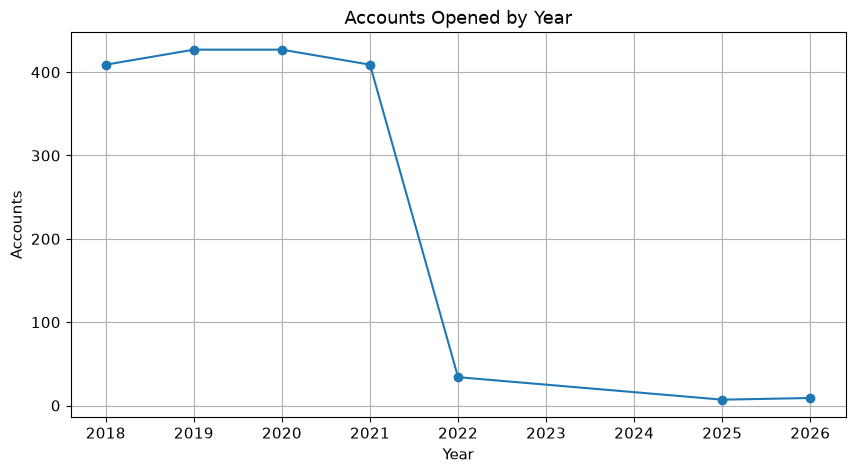

In [132]:
master["OpeningDate"] = pd.to_datetime(master["OpeningDate"])

master["OpeningYear"] = master["OpeningDate"].dt.year

plt.figure(figsize=(10,5))

master["OpeningYear"].value_counts().sort_index().plot(
    marker="o"
)

plt.title("Accounts Opened by Year")
plt.xlabel("Year")
plt.ylabel("Accounts")

plt.grid(True)

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/account_opened_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

In [112]:
master["DateOfBirth"] = pd.to_datetime(
    master["DateOfBirth"],
    errors="coerce"
)

In [114]:
today=pd.Timestamp.today()
master["DateOfBirth"]=pd.to_datetime(master["DateOfBirth"])
master["age"]=((today-master["DateOfBirth"]).dt.days//365)


In [118]:
master["age"]

0       52.0
1       52.0
2       63.0
3       62.0
4       60.0
        ... 
1996    45.0
1997    28.0
1998    28.0
1999    46.0
2000    53.0
Name: age, Length: 2001, dtype: float64

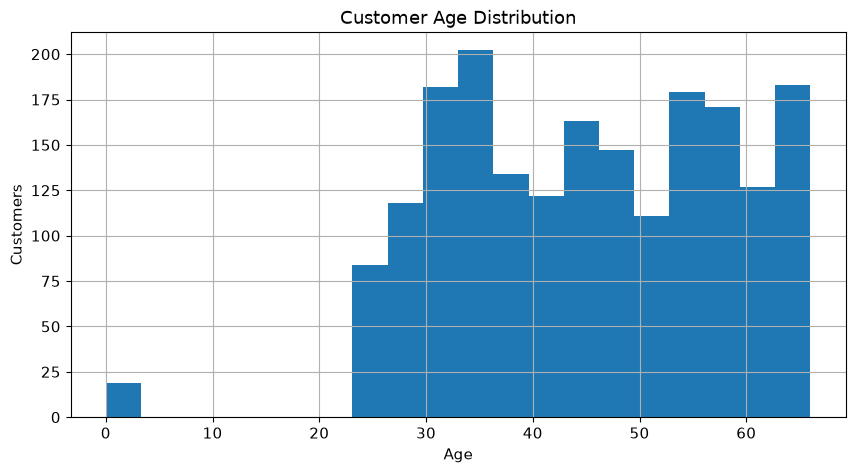

In [133]:
plt.figure(figsize=(10,5))

master["age"].hist(
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/customer_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

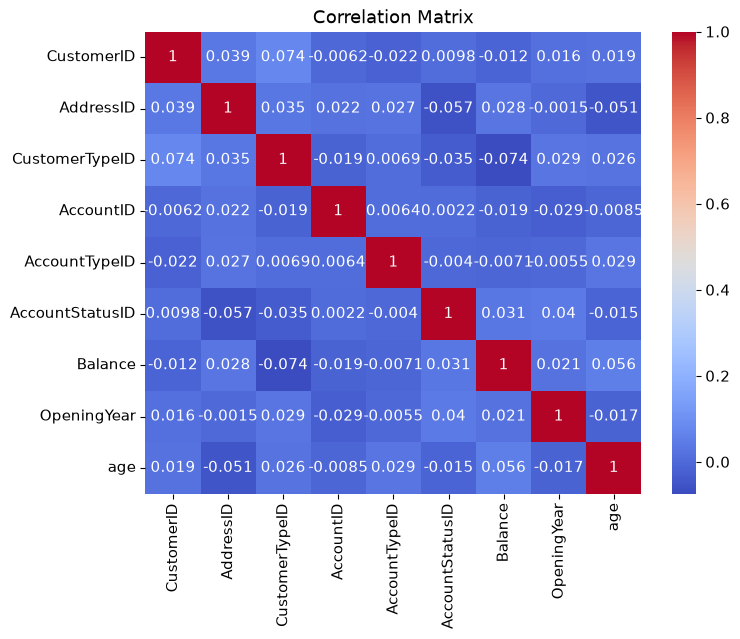

In [134]:
numeric = master.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [141]:
master["OpeningDate"]

0      2021-05-25
1      2021-12-12
2             NaT
3             NaT
4      2021-04-07
          ...    
1996          NaT
1997   2018-08-11
1998   2021-11-15
1999   2018-01-07
2000          NaT
Name: OpeningDate, Length: 2001, dtype: datetime64[us]

In [142]:
master["OpeningDate"] = pd.to_datetime(
    master["OpeningDate"],
    errors="coerce"
)

master["AccountAge"] = (
    (today - master["OpeningDate"]).dt.days / 365.25
).round().astype("Int64")

In [143]:
master.head(6)

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,CustomerType,AccountID,AccountTypeID,AccountStatusID,Balance,OpeningDate,AccountType,AccountStatus,LoanStatus,OpeningYear,age,AccountAge
0,10832,Nyla,Aguirre,1974-02-07,881,1,Columbia Square,Aurora,United States,Individual,200833.0,2.0,1.0,94714.26,2021-05-25,Savings,Active,Active,2021.0,52.0,5
1,10832,Nyla,Aguirre,1974-02-07,881,1,Columbia Square,Aurora,United States,Individual,200904.0,4.0,1.0,84891.94,2021-12-12,Business,Active,Active,2021.0,52.0,5
2,10983,NaN,Battle,1963-02-01,958,2,Coventry,Saco,United States,Small Business,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,63.0,<NA>
3,10837,Angelena,Harrington,1964-03-25,86,3,Wilson,Carlsbad,United States,Large Enterprise,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,62.0,<NA>
4,10107,Remona,Glass,1965-09-16,595,1,Koret,Grapevine,United States,Individual,200191.0,2.0,1.0,64668.96,2021-04-07,Savings,Active,Active,2021.0,60.0,5
5,10107,Remona,Glass,1965-09-16,595,1,Koret,Grapevine,United States,Individual,200882.0,3.0,1.0,87535.78,2021-01-06,Payroll,Active,Active,2021.0,60.0,6


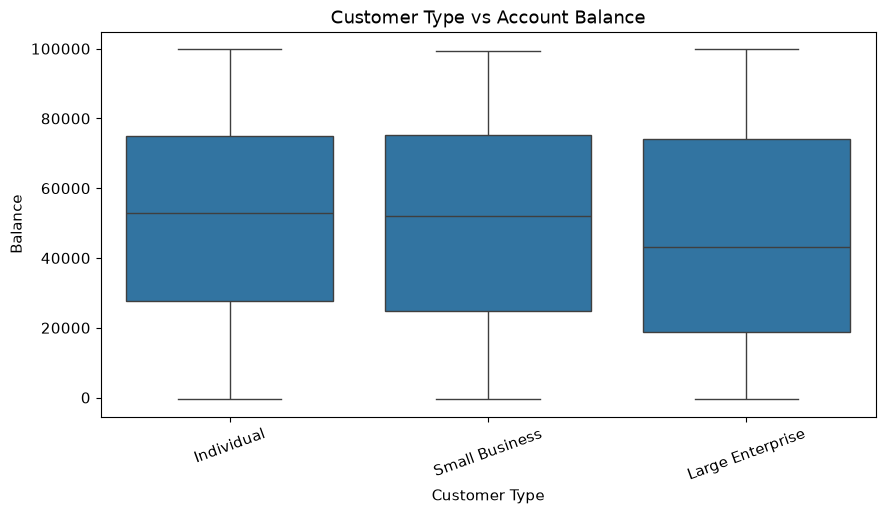

In [147]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="CustomerType",
    y="Balance",
    data=master
)

plt.title("Customer Type vs Account Balance")
plt.xlabel("Customer Type")
plt.ylabel("Balance")

plt.xticks(rotation=20)

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/cust_type_vs_balance.png", dpi=300, bbox_inches="tight")
plt.show()

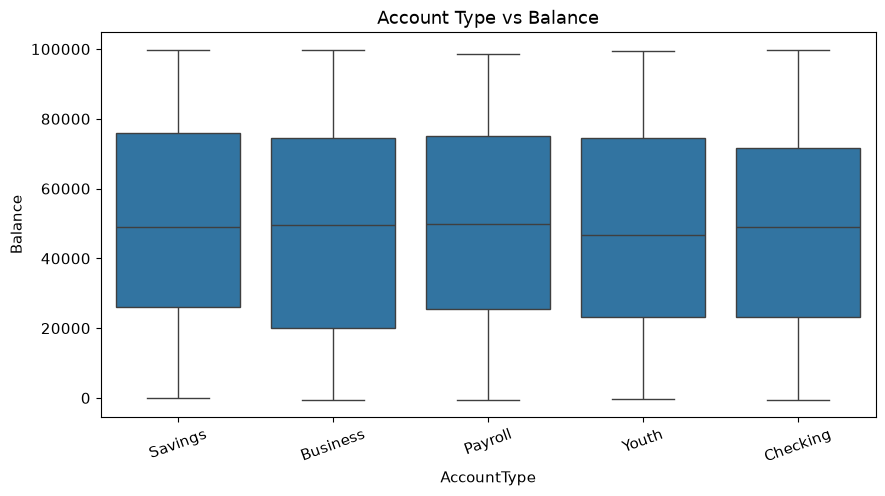

In [148]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="AccountType",
    y="Balance",
    data=master
)

plt.title("Account Type vs Balance")

plt.xticks(rotation=20)


plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/accoutype_vs_balance.png", dpi=300, bbox_inches="tight")
plt.show()

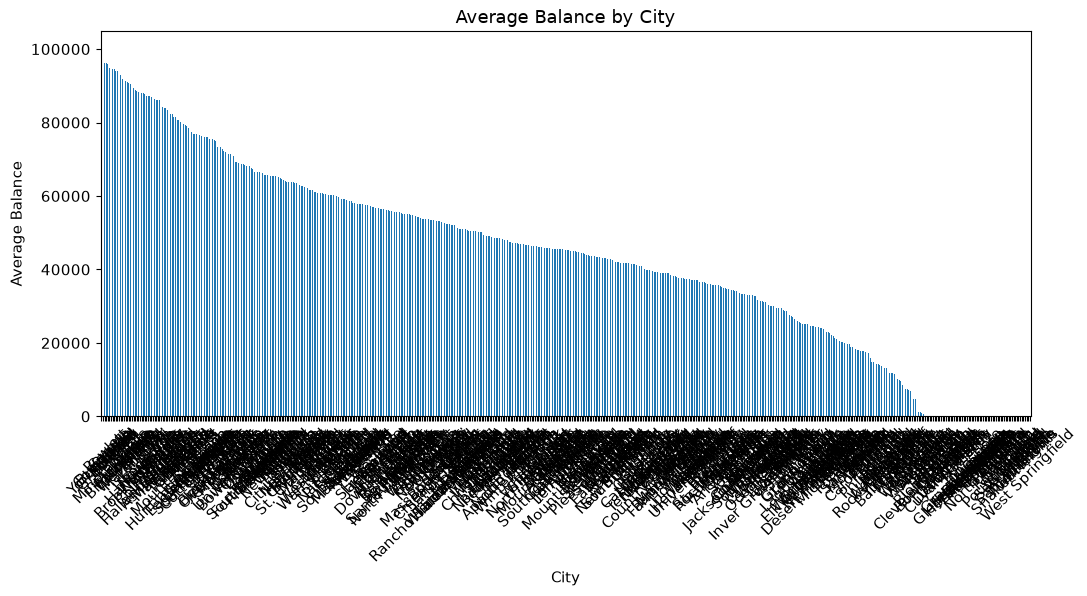

In [149]:
city_balance = (
    master.groupby("City")["Balance"]
          .mean()
          .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

city_balance.plot(kind="bar")

plt.title("Average Balance by City")
plt.xlabel("City")
plt.ylabel("Average Balance")

plt.xticks(rotation=45)

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/city_balance.png", dpi=300)

plt.show()

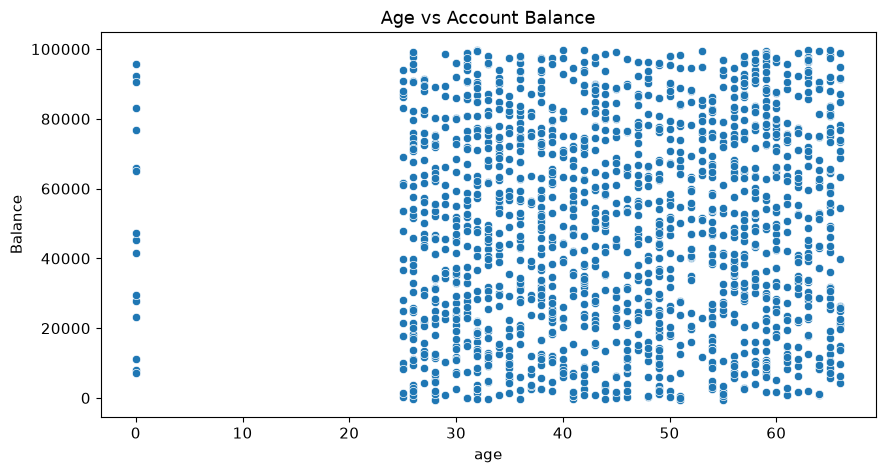

In [151]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=master,
    x="age",
    y="Balance"
)

plt.title("Age vs Account Balance")

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/age_balance.png", dpi=300)

plt.show()

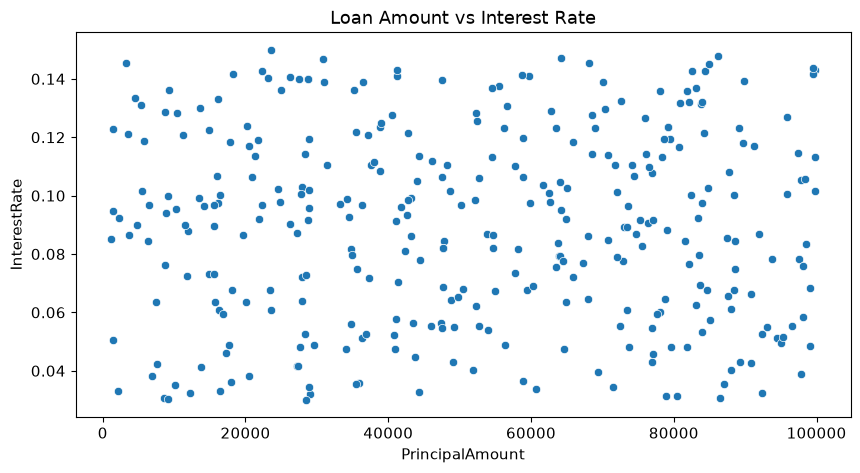

In [152]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=loans,
    x="PrincipalAmount",
    y="InterestRate"
)

plt.title("Loan Amount vs Interest Rate")

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/loan_interest.png", dpi=300)

plt.show()

In [153]:
transaction_analysis = transactions.merge(
    transaction_types,
    on="TransactionTypeID",
    how="left"
)

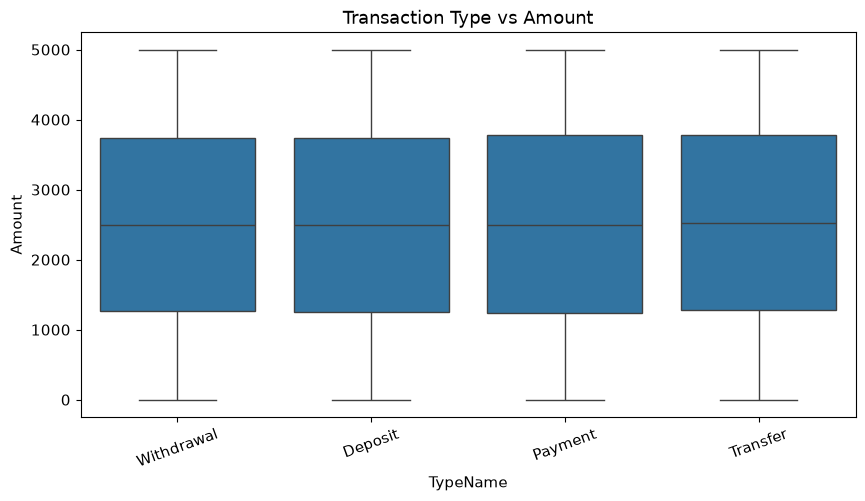

In [154]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=transaction_analysis,
    x="TypeName",
    y="Amount"
)

plt.title("Transaction Type vs Amount")

plt.xticks(rotation=20)

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/transactiontype_amount.png", dpi=300)

plt.show()

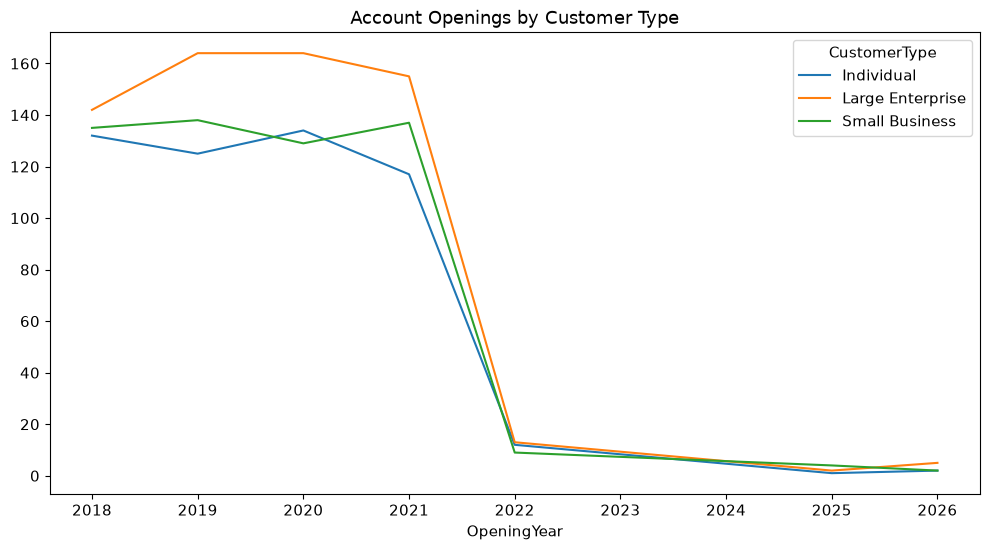

In [156]:
master["OpeningYear"] = pd.to_datetime(
    master["OpeningDate"]
).dt.year

opening = pd.crosstab(
    master["OpeningYear"],
    master["CustomerType"]
)

opening.plot(figsize=(12,6))

plt.title("Account Openings by Customer Type")

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/opening_customer.png", dpi=300)

plt.show()

In [157]:
print("="*70)
print("MODULE 1 COMPLETED")
print("="*70)

print(f"Number of Customers : {master['CustomerID'].nunique()}")
print(f"Number of Accounts  : {master['AccountID'].nunique()}")
print(f"Average Balance     : {master['Balance'].mean():,.2f}")
print(f"Maximum Balance     : {master['Balance'].max():,.2f}")
print(f"Minimum Balance     : {master['Balance'].min():,.2f}")

MODULE 1 COMPLETED
Number of Customers : 1100
Number of Accounts  : 1651
Average Balance     : 48,894.43
Maximum Balance     : 99,828.98
Minimum Balance     : -486.68


module 1 conclution


-the database dataset are merged in master dataset
-done univate analysis,bivariate and multivariate analysis
-the graphs are stored and analysis